# NBA draft data: exploratory data analysis

This notebook audits and explores every data artifact under **nba_draft_data_collection/data**. It is designed to answer four questions:

1. What data exists, at what grain, and over which seasons?
2. Where are the missingness, schema drift, duplicate-key, and domain-validity risks?
3. How do college, draft, combine, and NBA outcome tables connect?
4. What does the processed modeling population look like across time?

The implemented modeling task is regression on **nba_min_3y** (NBA minutes accumulated in the first three seasons), not a binary "flop" label. The binary **nba_reached_league_3y** field is shown only as a secondary outcome.

Methodology:

- Yearly files are partitions of one logical dataset.
- draft_all.parquet, base_all.parquet, and advanced_all.parquet are canonical rollups and are never concatenated with their yearly shards.
- Gzipped NBA API JSON files are provenance mirrors. Their row counts and schemas are checked against Parquet, but their observations are not counted twice.
- Exact Parquet metadata drives row counts and missingness. Large row-level tables are processed file by file; bounded deterministic samples are used only for plots.
- All nba_* three-year fields are post-draft outcomes and must not be used as predictors. Draft position/team fields are known only after selection and belong in a distinct post-selection baseline.

In [ ]:
from collections import defaultdict
from pathlib import Path, PurePosixPath
from zipfile import ZipFile
import gzip
import json
import math
import re
import sys
import warnings
import xml.etree.ElementTree as ET

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import seaborn as sns

try:
    from IPython.display import Markdown, display
except ImportError:
    class Markdown(str):
        pass

    def display(value):
        print(value)

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")
sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold"})

RANDOM_STATE = 42
PLOT_SAMPLE_ROWS = 100_000
np.random.seed(RANDOM_STATE)

In [2]:
def find_repo_root(start: Path | None = None) -> Path:
    """Find the repository whether the kernel starts in the root or notebooks/."""
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (
            (candidate / "nba_draft_data_collection" / "data").exists()
            and (candidate / "configs").exists()
        ):
            return candidate
    raise FileNotFoundError(
        "Could not find the repository root containing configs/ and "
        "nba_draft_data_collection/data/."
    )


REPO_ROOT = find_repo_root()
DATA_ROOT = REPO_ROOT / "nba_draft_data_collection" / "data"
RAW_ROOT = DATA_ROOT / "raw"
PROCESSED_ROOT = DATA_ROOT / "processed"
CONFIG_ROOT = REPO_ROOT / "configs"

print(f"Repository: {REPO_ROOT}")
print(f"Data root:  {DATA_ROOT}")

Repository: D:\Mestrado\nba-draft
Data root:  D:\Mestrado\nba-draft\nba_draft_data_collection\data


## 1. Complete physical-file inventory

The inventory includes Parquet tables, CSV audit outputs, the XLSX data dictionary, and all gzipped raw API responses. Aggregate rollups and JSON mirrors are labeled explicitly so they cannot inflate row counts.

In [3]:
PERIOD_PATTERN = re.compile(r"_((?:19|20)\d{2}(?:-\d{2})?)$")


def file_format(path: Path) -> str:
    return ".json.gz" if path.name.endswith(".json.gz") else path.suffix.lower()


def base_name(path: Path) -> str:
    name = path.name
    for suffix in (".json.gz", ".parquet", ".csv", ".xlsx"):
        if name.endswith(suffix):
            return name[: -len(suffix)]
    return path.stem


def extract_period(path: Path) -> str | None:
    match = PERIOD_PATTERN.search(base_name(path))
    return match.group(1) if match else None


data_files = sorted(path for path in DATA_ROOT.rglob("*") if path.is_file())
file_catalog = pd.DataFrame(
    [
        {
            "relative_path": path.relative_to(DATA_ROOT).as_posix(),
            "parent": path.parent.relative_to(DATA_ROOT).as_posix(),
            "format": file_format(path),
            "period": extract_period(path),
            "is_rollup": base_name(path).endswith("_all"),
            "is_json_mirror": ".json.gz" == file_format(path),
            "bytes": path.stat().st_size,
            "mib": path.stat().st_size / 1024**2,
        }
        for path in data_files
    ]
)

format_summary = (
    file_catalog.groupby("format", as_index=False)
    .agg(files=("relative_path", "size"), mib=("mib", "sum"))
    .sort_values("files", ascending=False)
)
directory_summary = (
    file_catalog.groupby(["parent", "format"], as_index=False)
    .agg(files=("relative_path", "size"), mib=("mib", "sum"))
    .sort_values(["parent", "format"])
)

display(
    Markdown(
        f"**{len(file_catalog):,} files** occupy "
        f"**{file_catalog['mib'].sum():,.2f} MiB**."
    )
)
display(format_summary)
display(directory_summary)

**323 files** occupy **88.22 MiB**.

,format,files,mib
2,.parquet,217,85.677
1,.json.gz,102,2.331
0,.csv,3,0.194
3,.xlsx,1,0.013


,parent,format,files,mib
0,processed,.parquet,2,1.080
1,processed,.xlsx,1,0.013
2,processed/audit,.csv,3,0.194
3,raw/college/player_box,.parquet,20,49.130
4,raw/college/player_core,.parquet,20,12.458
5,raw/college/player_season_from_box,.parquet,20,11.460
6,raw/college/player_stats,.parquet,14,0.011
7,raw/college/rosters,.parquet,14,0.011
8,raw/college/team_stats,.parquet,20,3.110
9,raw/crosswalks,.parquet,2,0.002


## 2. Logical datasets and exact structural audit

Each logical dataset below selects either one canonical rollup, a set of mutually exclusive yearly partitions, or one standalone processed/audit file. Physical files remain visible in the inventory even when they are not re-read as observations.

In [4]:
def build_dataset_specs() -> dict[str, dict]:
    specs: dict[str, dict] = {}
    parquet_directories = sorted({path.parent for path in DATA_ROOT.rglob("*.parquet")})

    for directory in parquet_directories:
        relative_parent = directory.relative_to(DATA_ROOT).as_posix()
        physical = sorted(directory.glob("*.parquet"))
        rollups = [path for path in physical if base_name(path).endswith("_all")]
        yearly = [path for path in physical if path not in rollups]

        standalone = relative_parent in {"processed", "raw/crosswalks"}
        if standalone:
            for path in physical:
                name = f"{relative_parent}/{base_name(path)}"
                specs[name] = {
                    "name": name,
                    "format": ".parquet",
                    "physical": [path],
                    "selected": [path],
                    "partitions": [path],
                    "selection": "standalone",
                }
        else:
            selected = rollups if rollups else yearly
            specs[relative_parent] = {
                "name": relative_parent,
                "format": ".parquet",
                "physical": physical,
                "selected": selected,
                "partitions": yearly if yearly else selected,
                "selection": "rollup" if rollups else "yearly partitions",
            }

    for path in sorted(DATA_ROOT.rglob("*.csv")):
        relative_parent = path.parent.relative_to(DATA_ROOT).as_posix()
        name = f"{relative_parent}/{base_name(path)}"
        specs[name] = {
            "name": name,
            "format": ".csv",
            "physical": [path],
            "selected": [path],
            "partitions": [path],
            "selection": "standalone",
        }

    return dict(sorted(specs.items()))


DATASET_SPECS = build_dataset_specs()
print(f"Logical tabular datasets: {len(DATASET_SPECS)}")

Logical tabular datasets: 20


In [5]:
def parquet_info(path: Path) -> dict:
    parquet_file = pq.ParquetFile(path)
    schema = parquet_file.schema_arrow
    return {
        "path": path,
        "rows": parquet_file.metadata.num_rows,
        "columns": schema.names,
        "types": {field.name: str(field.type) for field in schema},
        "schema": tuple(sorted((field.name, str(field.type)) for field in schema)),
        "parquet_file": parquet_file,
    }


def parquet_missingness(paths: list[Path]) -> pd.DataFrame:
    infos = [parquet_info(path) for path in paths]
    total_rows = sum(info["rows"] for info in infos)
    ordered_columns = list(
        dict.fromkeys(column for info in infos for column in info["columns"])
    )
    records = []

    for column in ordered_columns:
        null_count = 0
        exact = True
        types = set()
        for info in infos:
            if column not in info["columns"]:
                null_count += info["rows"]
                continue

            types.add(info["types"][column])
            column_index = info["columns"].index(column)
            parquet_file = info["parquet_file"]
            for row_group_index in range(parquet_file.num_row_groups):
                statistics = parquet_file.metadata.row_group(row_group_index).column(
                    column_index
                ).statistics
                if statistics is None or statistics.null_count is None:
                    exact = False
                else:
                    null_count += statistics.null_count

        records.append(
            {
                "column": column,
                "dtype": " | ".join(sorted(types)),
                "missing_rows": null_count if exact else np.nan,
                "missing_pct": (
                    100 * null_count / total_rows if exact and total_rows else np.nan
                ),
                "stats_exact": exact,
            }
        )

    return pd.DataFrame(
        records,
        columns=["column", "dtype", "missing_rows", "missing_pct", "stats_exact"],
    )


def schema_variant_rows(spec: dict) -> list[dict]:
    if spec["format"] != ".parquet":
        return []
    grouped: dict[tuple, list[Path]] = defaultdict(list)
    for path in spec["partitions"]:
        grouped[parquet_info(path)["schema"]].append(path)
    union = {column for signature in grouped for column, _ in signature}
    rows = []
    for variant, (signature, paths) in enumerate(grouped.items(), start=1):
        columns = {column for column, _ in signature}
        rows.append(
            {
                "dataset": spec["name"],
                "variant": variant,
                "files": len(paths),
                "periods": ", ".join(
                    str(period)
                    for period in (extract_period(path) for path in paths)
                    if period is not None
                ),
                "columns": len(columns),
                "missing_from_family_schema": ", ".join(sorted(union - columns)) or "—",
            }
        )
    return rows


def profile_dataset(spec: dict) -> dict:
    if spec["format"] == ".parquet":
        selected_infos = [parquet_info(path) for path in spec["selected"]]
        rows = sum(info["rows"] for info in selected_infos)
        missing = parquet_missingness(spec["selected"])
        schema_variants = len(
            {parquet_info(path)["schema"] for path in spec["partitions"]}
        )
        columns = int(missing.shape[0])
    else:
        frame = pd.read_csv(spec["selected"][0])
        rows, columns = frame.shape
        missing = pd.DataFrame(
            {
                "column": frame.columns,
                "dtype": frame.dtypes.astype(str).values,
                "missing_rows": frame.isna().sum().values,
                "missing_pct": frame.isna().mean().mul(100).values,
                "stats_exact": True,
            }
        )
        schema_variants = 1

    missing_cells = missing["missing_rows"].sum() if not missing.empty else 0
    missing_cell_pct = (
        100 * missing_cells / (rows * columns) if rows and columns else np.nan
    )
    all_null_columns = (
        int(missing["missing_rows"].eq(rows).sum()) if rows and columns else 0
    )

    return {
        "dataset": spec["name"],
        "format": spec["format"],
        "selection": spec["selection"],
        "physical_files": len(spec["physical"]),
        "analysis_files": len(spec["selected"]),
        "rows": rows,
        "columns": columns,
        "schema_variants": schema_variants,
        "missing_cell_pct": missing_cell_pct,
        "all_null_columns": all_null_columns,
        "selected_mib": sum(path.stat().st_size for path in spec["selected"]) / 1024**2,
        "empty": rows == 0 or columns == 0,
        "missing": missing,
    }


PROFILES = {
    name: profile_dataset(spec) for name, spec in DATASET_SPECS.items()
}
dataset_summary = pd.DataFrame(
    [
        {key: value for key, value in profile.items() if key != "missing"}
        for profile in PROFILES.values()
    ]
).sort_values(["empty", "dataset"])

display(dataset_summary.reset_index(drop=True))

,dataset,format,selection,physical_files,analysis_files,rows,columns,schema_variants,missing_cell_pct,all_null_columns,selected_mib,empty
0,processed/audit/ambiguous_name_matches,.csv,standalone,1,1,20,8,1,0.000,0,0.002,False
1,processed/audit/drafted_players_without_colleg...,.csv,standalone,1,1,179,194,1,77.446,73,0.096,False
2,processed/audit/drafted_players_without_identi...,.csv,standalone,1,1,179,194,1,77.446,73,0.096,False
3,processed/drafted_players_all,.parquet,standalone,1,1,838,194,1,43.053,0,0.559,False
4,processed/model_dataset_drafted_college,.parquet,standalone,1,1,659,194,1,33.714,0,0.521,False
5,raw/college/player_box,.parquet,yearly partitions,20,20,2877082,55,2,10.664,0,49.130,False
6,raw/college/player_core,.parquet,yearly partitions,20,20,149688,36,1,18.958,0,12.458,False
7,raw/college/player_season_from_box,.parquet,yearly partitions,20,20,151254,40,1,7.767,0,11.460,False
8,raw/college/team_stats,.parquet,yearly partitions,20,20,528480,16,1,21.144,3,3.110,False
9,raw/nba/combine/anthro,.parquet,yearly partitions,14,14,858,18,3,2.603,0,0.215,False


In [6]:
empty_datasets = dataset_summary.loc[
    dataset_summary["empty"],
    ["dataset", "physical_files", "rows", "columns"],
]
drift_records = [
    row
    for spec in DATASET_SPECS.values()
    for row in schema_variant_rows(spec)
]
schema_drift = pd.DataFrame(drift_records)
schema_drift = schema_drift[
    schema_drift.groupby("dataset")["variant"].transform("max").gt(1)
] if not schema_drift.empty else schema_drift

top_missing_records = []
for name, profile in PROFILES.items():
    missing = profile["missing"]
    if missing.empty:
        continue
    for row in missing.sort_values(
        ["missing_pct", "column"], ascending=[False, True]
    ).head(6).itertuples(index=False):
        top_missing_records.append(
            {
                "dataset": name,
                "column": row.column,
                "missing_rows": row.missing_rows,
                "missing_pct": row.missing_pct,
                "metadata_exact": row.stats_exact,
            }
        )
top_missing_by_dataset = pd.DataFrame(top_missing_records)

display(Markdown("### Empty or unavailable logical datasets"))
display(empty_datasets.reset_index(drop=True))
display(Markdown("### Schema variants across yearly partitions"))
display(schema_drift.reset_index(drop=True))
display(Markdown("### Six most-missing columns in every non-empty dataset"))
display(top_missing_by_dataset.reset_index(drop=True))

### Empty or unavailable logical datasets

,dataset,physical_files,rows,columns
0,raw/college/player_stats,14,0,0
1,raw/college/rosters,14,0,0
2,raw/crosswalks/mbb_player_crosswalk,1,0,0
3,raw/crosswalks/nba_player_crosswalk,1,0,0


### Schema variants across yearly partitions

,dataset,variant,files,periods,columns,missing_from_family_schema
0,raw/college/player_box,1,10,"2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010...",54,athlete_headshot_href
1,raw/college/player_box,2,10,"2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020...",55,—
2,raw/nba/combine/anthro,1,1,2009,18,—
3,raw/nba/combine/anthro,2,4,"2010, 2011, 2012, 2013",18,—
4,raw/nba/combine/anthro,3,9,"2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021...",18,—
5,raw/nba/combine/drills,1,4,"2009, 2010, 2011, 2012",12,—
6,raw/nba/combine/drills,2,1,2013,12,—
7,raw/nba/combine/drills,3,5,"2014, 2016, 2020, 2021, 2022",12,—
8,raw/nba/combine/drills,4,4,"2015, 2017, 2018, 2019",12,—
9,raw/nba/combine/nonstationary_shooting,1,5,"2009, 2010, 2011, 2012, 2013",30,—


### Six most-missing columns in every non-empty dataset

,dataset,column,missing_rows,missing_pct,metadata_exact
0,processed/audit/ambiguous_name_matches,candidate_espn_athlete_id,0.000,0.000,True
1,processed/audit/ambiguous_name_matches,candidate_first_season,0.000,0.000,True
2,processed/audit/ambiguous_name_matches,candidate_last_season,0.000,0.000,True
3,processed/audit/ambiguous_name_matches,candidate_name,0.000,0.000,True
4,processed/audit/ambiguous_name_matches,draft_organization,0.000,0.000,True
5,processed/audit/ambiguous_name_matches,draft_player_name,0.000,0.000,True
6,processed/audit/drafted_players_without_colleg...,age_on_draft_year_july1,179.000,100.000,True
7,processed/audit/drafted_players_without_colleg...,college_career_assist_turnover_ratio,179.000,100.000,True
8,processed/audit/drafted_players_without_colleg...,college_career_assists,179.000,100.000,True
9,processed/audit/drafted_players_without_colleg...,college_career_assists_per_40,179.000,100.000,True


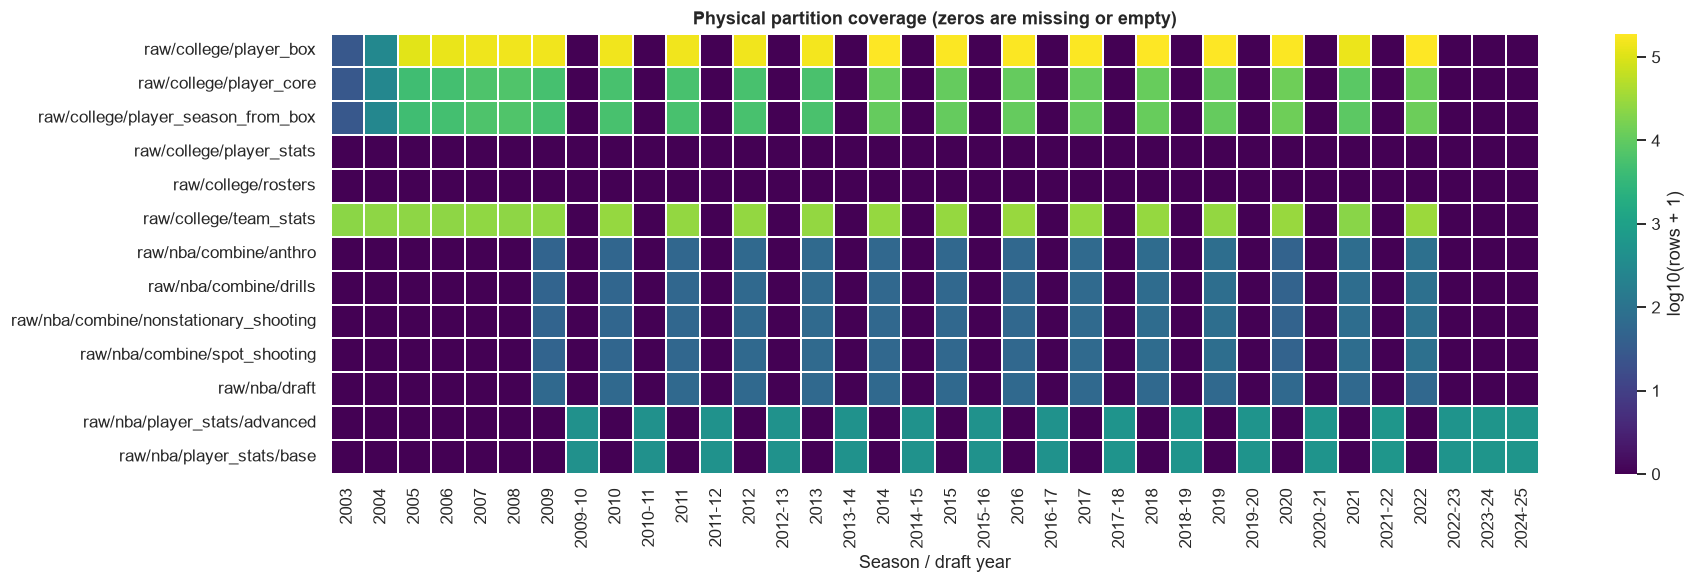

In [7]:
partition_records = []
for name, spec in DATASET_SPECS.items():
    if spec["format"] != ".parquet":
        continue
    for path in spec["partitions"]:
        period = extract_period(path)
        if period is None:
            continue
        info = parquet_info(path)
        partition_records.append(
            {
                "dataset": name,
                "period": period,
                "rows": info["rows"],
                "columns": len(info["columns"]),
                "file": path.name,
            }
        )

partition_coverage = pd.DataFrame(partition_records)
coverage_matrix = (
    partition_coverage.pivot_table(
        index="dataset", columns="period", values="rows", aggfunc="sum"
    )
    .fillna(0)
    .sort_index()
)

fig, ax = plt.subplots(figsize=(17, max(5, 0.42 * len(coverage_matrix))))
sns.heatmap(
    np.log10(coverage_matrix + 1),
    cmap="viridis",
    linewidths=0.25,
    cbar_kws={"label": "log10(rows + 1)"},
    ax=ax,
)
ax.set_title("Physical partition coverage (zeros are missing or empty)")
ax.set_xlabel("Season / draft year")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 3. Provenance mirrors and workbook metadata

The NBA JSON responses are retained for provenance. This section opens every archive and verifies it against its normalized yearly Parquet mirror. The XLSX workbook is read with the Python standard library, so the notebook does not require openpyxl.

In [8]:
JSON_ROOT = RAW_ROOT / "nba" / "raw_json"


def inspect_json_mirror(path: Path) -> dict:
    try:
        with gzip.open(path, "rt", encoding="utf-8") as file:
            payload = json.load(file)
        result_sets = payload.get("resultSets", payload.get("resultSet", []))
        if isinstance(result_sets, dict):
            result_sets = [result_sets]
        rows = sum(len(result_set.get("rowSet", [])) for result_set in result_sets)
        headers = {
            header
            for result_set in result_sets
            for header in result_set.get("headers", [])
        }
        error = None
    except Exception as exc:
        rows, headers, error = np.nan, set(), repr(exc)

    relative = path.relative_to(JSON_ROOT)
    parquet_name = path.name.removesuffix(".json.gz") + ".parquet"
    mirror = DATA_ROOT / "raw" / "nba" / relative.parent / parquet_name
    if mirror.exists():
        info = parquet_info(mirror)
        parquet_rows = info["rows"]
        parquet_headers = set(info["columns"])
    else:
        parquet_rows, parquet_headers = np.nan, set()

    return {
        "family": relative.parent.as_posix(),
        "json_file": relative.as_posix(),
        "json_rows": rows,
        "json_columns": len(headers),
        "mirror_exists": mirror.exists(),
        "parquet_rows": parquet_rows,
        "parquet_columns": len(parquet_headers) if mirror.exists() else np.nan,
        "row_match": mirror.exists() and rows == parquet_rows,
        "schema_match": mirror.exists() and headers == parquet_headers,
        "error": error,
    }


json_audit = pd.DataFrame(
    [inspect_json_mirror(path) for path in sorted(JSON_ROOT.rglob("*.json.gz"))]
)
json_family_summary = (
    json_audit.groupby("family", as_index=False)
    .agg(
        json_files=("json_file", "size"),
        json_rows=("json_rows", "sum"),
        mirrors_found=("mirror_exists", "sum"),
        row_matches=("row_match", "sum"),
        schema_matches=("schema_match", "sum"),
        read_errors=("error", lambda series: series.notna().sum()),
    )
)

display(json_family_summary)
display(
    Markdown(
        f"Exact row parity: **{json_audit['row_match'].sum():,}/"
        f"{len(json_audit):,}** files. Exact schema parity: "
        f"**{json_audit['schema_match'].sum():,}/{len(json_audit):,}** files."
    )
)
if not json_audit[["row_match", "schema_match"]].all(axis=1).all():
    display(json_audit.loc[~json_audit[["row_match", "schema_match"]].all(axis=1)])

,family,json_files,json_rows,mirrors_found,row_matches,schema_matches,read_errors
0,combine/anthro,14,858,14,14,14,0
1,combine/drills,14,858,14,14,14,0
2,combine/nonstationary_shooting,14,858,14,14,14,0
3,combine/spot_shooting,14,858,14,14,14,0
4,draft,14,838,14,14,14,0
5,player_stats/advanced,16,8201,16,16,16,0
6,player_stats/base,16,8201,16,16,16,0


Exact row parity: **102/102** files. Exact schema parity: **102/102** files.

In [9]:
SPREADSHEET_NS = "http://schemas.openxmlformats.org/spreadsheetml/2006/main"
DOCUMENT_REL_NS = "http://schemas.openxmlformats.org/officeDocument/2006/relationships"
PACKAGE_REL_NS = "http://schemas.openxmlformats.org/package/2006/relationships"


def excel_column_index(reference: str) -> int:
    letters = re.match(r"[A-Z]+", reference).group()
    value = 0
    for letter in letters:
        value = value * 26 + ord(letter) - ord("A") + 1
    return value - 1


def read_simple_xlsx(path: Path) -> dict[str, pd.DataFrame]:
    """Read ordinary cell values from this workbook without an Excel engine."""
    tables = {}
    main = f"{{{SPREADSHEET_NS}}}"
    with ZipFile(path) as archive:
        workbook = ET.fromstring(archive.read("xl/workbook.xml"))
        relationships = ET.fromstring(
            archive.read("xl/_rels/workbook.xml.rels")
        )
        targets = {
            relationship.attrib["Id"]: relationship.attrib["Target"]
            for relationship in relationships.findall(
                f"{{{PACKAGE_REL_NS}}}Relationship"
            )
        }

        shared_strings = []
        if "xl/sharedStrings.xml" in archive.namelist():
            shared_root = ET.fromstring(archive.read("xl/sharedStrings.xml"))
            for item in shared_root.findall(f"{main}si"):
                shared_strings.append(
                    "".join(node.text or "" for node in item.iter(f"{main}t"))
                )

        for sheet in workbook.find(f"{main}sheets"):
            sheet_name = sheet.attrib["name"]
            relationship_id = sheet.attrib[f"{{{DOCUMENT_REL_NS}}}id"]
            target = targets[relationship_id].lstrip("/")
            if not target.startswith("xl/"):
                target = str(PurePosixPath("xl") / target)

            sheet_root = ET.fromstring(archive.read(target))
            sparse_rows = []
            max_column = -1
            for row in sheet_root.findall(f".//{main}row"):
                values = {}
                for cell in row.findall(f"{main}c"):
                    column_index = excel_column_index(cell.attrib["r"])
                    max_column = max(max_column, column_index)
                    cell_type = cell.attrib.get("t")
                    value_node = cell.find(f"{main}v")

                    if cell_type == "inlineStr":
                        value = "".join(
                            node.text or "" for node in cell.iter(f"{main}t")
                        )
                    elif value_node is None:
                        value = None
                    elif cell_type == "s":
                        value = shared_strings[int(value_node.text)]
                    elif cell_type in {"str", "e"}:
                        value = value_node.text
                    else:
                        text_value = value_node.text
                        try:
                            number = float(text_value)
                            value = int(number) if number.is_integer() else number
                        except (TypeError, ValueError):
                            value = text_value
                    values[column_index] = value
                sparse_rows.append(values)

            matrix = [
                [row.get(index) for index in range(max_column + 1)]
                for row in sparse_rows
            ]
            if not matrix:
                tables[sheet_name] = pd.DataFrame()
                continue
            headers = [
                str(value) if value is not None else f"column_{index}"
                for index, value in enumerate(matrix[0])
            ]
            tables[sheet_name] = pd.DataFrame(matrix[1:], columns=headers)

    return tables


dictionary_path = PROCESSED_ROOT / "nba_draft_dataframe_data_dictionary.xlsx"
workbook_tables = read_simple_xlsx(dictionary_path)
data_dictionary = workbook_tables["Data Dictionary"]
benchmark_guide = workbook_tables["Benchmark Guide"]

dictionary_columns = set(data_dictionary["Column"])
processed_columns = set(
    PROFILES["processed/drafted_players_all"]["missing"]["column"]
)
dictionary_check = pd.DataFrame(
    {
        "check": ["dictionary rows", "missing from dictionary", "extra in dictionary"],
        "value": [
            len(data_dictionary),
            len(processed_columns - dictionary_columns),
            len(dictionary_columns - processed_columns),
        ],
        "examples": [
            "",
            ", ".join(sorted(processed_columns - dictionary_columns)[:10]),
            ", ".join(sorted(dictionary_columns - processed_columns)[:10]),
        ],
    }
)

display(pd.DataFrame(
    [{"sheet": name, "rows": len(table), "columns": table.shape[1]}
     for name, table in workbook_tables.items()]
))
display(dictionary_check)
display(
    data_dictionary.groupby(
        ["Group", "Role", "Temporal / Leakage Status"], dropna=False
    ).size().rename("columns").reset_index()
)
display(Markdown("### Benchmark guide"))
display(benchmark_guide)

,sheet,rows,columns
0,Data Dictionary,194,6
1,Benchmark Guide,8,3


,check,value,examples
0,dictionary rows,194,
1,missing from dictionary,0,
2,extra in dictionary,0,


,Group,Role,Temporal / Leakage Status,columns
0,College: career,Feature,Pre-draft,34
1,College: career,Metadata,Pre-draft,2
2,College: last season,Categorical feature,Pre-draft,1
3,College: last season,Feature,Pre-draft,24
4,College: last season,Metadata,Pre-draft,1
5,College: player core,Categorical feature,Pre-draft,2
6,Combine,Missingness flag,Pre-draft,1
7,Combine: anthropometrics,Feature,Pre-draft,8
8,Combine: athletic drills,Feature,Pre-draft,6
9,Combine: movement shooting,Detailed feature,Pre-draft,24


### Benchmark guide

,Item,Recommendation,Why
0,Primary target,log1p(nba_min_3y),Early NBA opportunity/traction; avoids an arbi...
1,Benchmark 0,overall_pick only,Quantifies the information already contained i...
2,Benchmark A,Compact college-only set,Use the fields marked 'Yes — Benchmark A'.
3,Benchmark B,Benchmark A + core combine,"Add anthropometrics, athletic drills, and comb..."
4,Benchmark C,Benchmark B + overall_pick,Measures additional signal from draft position.
5,Detailed combine shooting,Later ablation,"Sparse, noisy, small-sample drill measurements."
6,NBA columns,Never use as predictors,They are post-draft outcomes and would leak fu...
7,draft_year,Split variable,Use chronological rather than random splits.


## 4. Reusable loading and key-quality helpers

The helpers below preserve schema drift, add source-file/source-period columns to partitioned collections, and sample proportionally when a plot limit is requested.

In [10]:
def selected_file_row_count(path: Path, file_type: str) -> int:
    if file_type == ".parquet":
        return parquet_info(path)["rows"]
    return len(pd.read_csv(path))


def load_one_file(
    path: Path,
    file_type: str,
    columns: list[str] | None = None,
    source_columns: bool = True,
) -> pd.DataFrame:
    requested = list(dict.fromkeys(columns)) if columns is not None else None

    if file_type == ".parquet":
        available = parquet_info(path)["columns"]
        read_columns = (
            [column for column in requested if column in available]
            if requested is not None
            else None
        )
        frame = pd.read_parquet(path, columns=read_columns)
    elif file_type == ".csv":
        available = list(pd.read_csv(path, nrows=0).columns)
        read_columns = (
            [column for column in requested if column in available]
            if requested is not None
            else None
        )
        frame = pd.read_csv(path, usecols=read_columns)
    else:
        raise ValueError(f"Unsupported tabular format: {file_type}")

    if requested is not None:
        for column in requested:
            if column not in frame:
                frame[column] = pd.NA

    if source_columns:
        frame["_source_file"] = path.name
        frame["_source_period"] = extract_period(path)
    return frame


def load_dataset(
    name: str,
    columns: list[str] | None = None,
    max_rows: int | None = None,
) -> pd.DataFrame:
    spec = DATASET_SPECS[name]
    paths = spec["selected"]
    row_counts = [
        selected_file_row_count(path, spec["format"]) for path in paths
    ]
    total_rows = sum(row_counts)
    frames = []

    for path, rows in zip(paths, row_counts):
        frame = load_one_file(path, spec["format"], columns=columns)
        if max_rows is not None and total_rows > max_rows and len(frame):
            allocation = max(1, round(max_rows * rows / total_rows))
            if len(frame) > allocation:
                frame = frame.sample(allocation, random_state=RANDOM_STATE)
        frames.append(frame)

    if not frames:
        return pd.DataFrame(columns=columns)
    combined = pd.concat(frames, ignore_index=True, sort=False)
    if max_rows is not None and len(combined) > max_rows:
        combined = combined.sample(max_rows, random_state=RANDOM_STATE)
    return combined.reset_index(drop=True)


KEY_COLUMNS = {
    "raw/college/player_box": ["season", "game_id", "athlete_id", "team_id"],
    "raw/college/player_core": ["season", "athlete_id"],
    "raw/college/player_season_from_box": ["season", "athlete_id", "team_id"],
    "raw/college/team_stats": ["season", "team_id", "category", "stat_name"],
    "raw/nba/combine/anthro": ["_source_period", "PLAYER_ID"],
    "raw/nba/combine/drills": ["_source_period", "PLAYER_ID"],
    "raw/nba/combine/nonstationary_shooting": [
        "_source_period", "TEMP_PLAYER_ID"
    ],
    "raw/nba/combine/spot_shooting": ["_source_period", "PLAYER_ID"],
    "raw/nba/draft": ["SEASON", "PERSON_ID"],
    "raw/nba/player_stats/advanced": ["SEASON", "PLAYER_ID"],
    "raw/nba/player_stats/base": ["SEASON", "PLAYER_ID"],
    "processed/drafted_players_all": ["draft_year", "nba_player_id"],
    "processed/model_dataset_drafted_college": [
        "draft_year", "nba_player_id"
    ],
}


def audit_key(name: str, keys: list[str]) -> dict:
    """Exact within-partition key audit; all partitioned keys include season."""
    spec = DATASET_SPECS[name]
    duplicate_rows = 0
    duplicate_groups = 0
    null_key_rows = 0
    scanned_rows = 0

    for path in spec["selected"]:
        frame = load_one_file(path, spec["format"], columns=keys)
        scanned_rows += len(frame)
        null_key_rows += int(frame[keys].isna().any(axis=1).sum())
        duplicated = frame.duplicated(keys, keep=False)
        duplicate_rows += int(duplicated.sum())
        if duplicated.any():
            duplicate_groups += int(
                frame.loc[duplicated].value_counts(
                    subset=keys, dropna=False
                ).gt(1).sum()
            )

    return {
        "dataset": name,
        "key": " + ".join(keys),
        "rows_scanned": scanned_rows,
        "null_key_rows": null_key_rows,
        "duplicate_rows": duplicate_rows,
        "duplicate_key_groups": duplicate_groups,
    }


key_quality = pd.DataFrame(
    [audit_key(name, keys) for name, keys in KEY_COLUMNS.items()]
)
display(key_quality)

,dataset,key,rows_scanned,null_key_rows,duplicate_rows,duplicate_key_groups
0,raw/college/player_box,season + game_id + athlete_id + team_id,2877082,90,27,6
1,raw/college/player_core,season + athlete_id,149688,0,0,0
2,raw/college/player_season_from_box,season + athlete_id + team_id,151254,37,70,35
3,raw/college/team_stats,season + team_id + category + stat_name,528480,0,0,0
4,raw/nba/combine/anthro,_source_period + PLAYER_ID,858,0,0,0
5,raw/nba/combine/drills,_source_period + PLAYER_ID,858,0,0,0
6,raw/nba/combine/nonstationary_shooting,_source_period + TEMP_PLAYER_ID,858,276,276,5
7,raw/nba/combine/spot_shooting,_source_period + PLAYER_ID,858,0,0,0
8,raw/nba/draft,SEASON + PERSON_ID,838,0,0,0
9,raw/nba/player_stats/advanced,SEASON + PLAYER_ID,8201,0,0,0


## 5. NCAA source data

The raw college data covers 2003–2022 because early seasons can contribute to the careers of later draftees. Player-box validation is streamed one year at a time to avoid materializing the 2.88-million-row, 55-column table.

,season,rows,games,players,teams,dnp_rate_pct,null_athlete_ids
0,2003,26,1,26,2,11.538,0
1,2004,289,11,276,21,20.069,0
2,2005,112140,4171,4603,340,24.847,0
3,2006,126329,4702,4945,364,24.983,0
4,2007,140099,5195,6536,497,24.907,0
5,2008,145160,5386,6807,518,24.403,0
6,2009,145485,5493,5303,468,24.589,0
7,2010,149692,5569,5568,499,24.866,0
8,2011,146552,5556,5455,495,24.197,1
9,2012,148383,5603,5493,507,24.718,0


,check,failures
0,duplicate_key_rows,27
1,null_athlete_ids,90
2,negative_box_values,0
3,made_over_attempt_rows,1
4,rebound_identity_mismatches,0
5,point_identity_mismatches,30
6,filename_season_mismatches,0


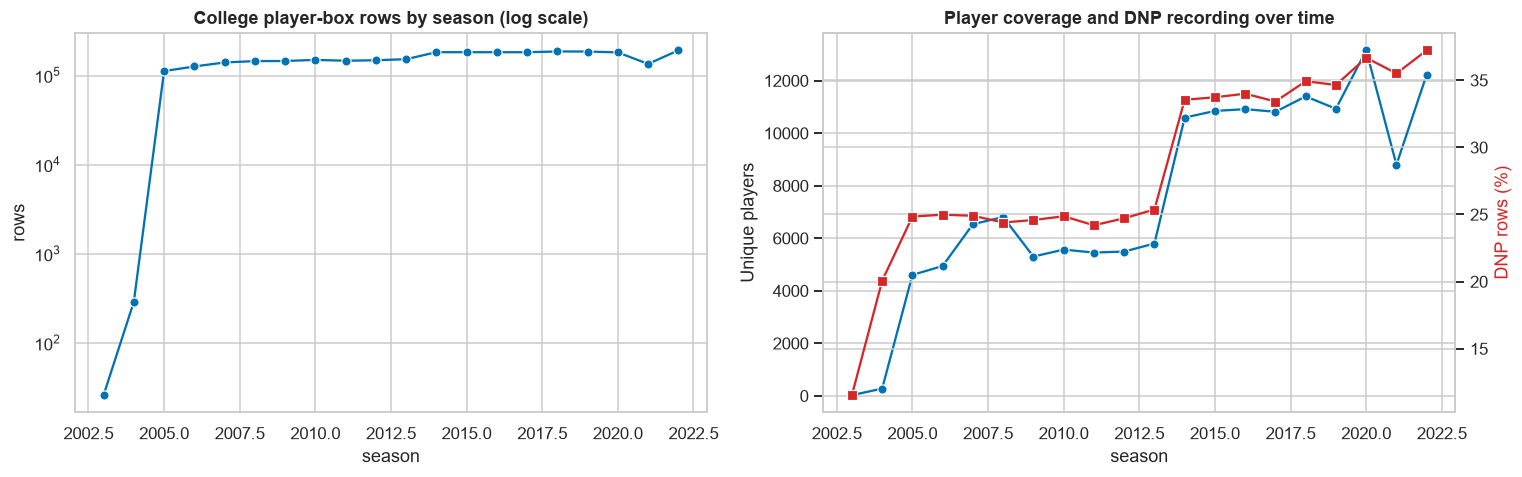

In [11]:
BOX_COLUMNS = [
    "season", "game_id", "athlete_id", "team_id", "did_not_play",
    "minutes", "field_goals_made", "field_goals_attempted",
    "three_point_field_goals_made", "three_point_field_goals_attempted",
    "free_throws_made", "free_throws_attempted",
    "offensive_rebounds", "defensive_rebounds", "rebounds",
    "points",
]


def audit_player_box() -> tuple[pd.DataFrame, pd.DataFrame]:
    coverage_rows = []
    check_totals = defaultdict(int)

    spec = DATASET_SPECS["raw/college/player_box"]
    for path in spec["selected"]:
        frame = load_one_file(path, ".parquet", columns=BOX_COLUMNS)
        numeric_columns = [
            column for column in BOX_COLUMNS
            if column not in {
                "season", "game_id", "athlete_id", "team_id", "did_not_play"
            }
        ]
        numeric = frame[numeric_columns].apply(pd.to_numeric, errors="coerce")

        key = ["season", "game_id", "athlete_id", "team_id"]
        check_totals["duplicate_key_rows"] += int(
            frame.duplicated(key, keep=False).sum()
        )
        check_totals["null_athlete_ids"] += int(frame["athlete_id"].isna().sum())
        check_totals["negative_box_values"] += int(numeric.lt(0).any(axis=1).sum())

        made_attempt_pairs = [
            ("field_goals_made", "field_goals_attempted"),
            ("three_point_field_goals_made", "three_point_field_goals_attempted"),
            ("free_throws_made", "free_throws_attempted"),
        ]
        made_over_attempt = pd.Series(False, index=frame.index)
        for made, attempted in made_attempt_pairs:
            comparable = numeric[[made, attempted]].notna().all(axis=1)
            made_over_attempt |= comparable & numeric[made].gt(numeric[attempted])
        check_totals["made_over_attempt_rows"] += int(made_over_attempt.sum())

        rebound_fields = [
            "offensive_rebounds", "defensive_rebounds", "rebounds"
        ]
        valid_rebounds = numeric[rebound_fields].notna().all(axis=1)
        rebound_mismatch = valid_rebounds & ~np.isclose(
            numeric["offensive_rebounds"] + numeric["defensive_rebounds"],
            numeric["rebounds"],
        )
        check_totals["rebound_identity_mismatches"] += int(
            rebound_mismatch.sum()
        )

        point_fields = [
            "field_goals_made", "three_point_field_goals_made",
            "free_throws_made", "points",
        ]
        valid_points = numeric[point_fields].notna().all(axis=1)
        expected_points = (
            2 * numeric["field_goals_made"]
            + numeric["three_point_field_goals_made"]
            + numeric["free_throws_made"]
        )
        point_mismatch = valid_points & ~np.isclose(
            expected_points, numeric["points"]
        )
        check_totals["point_identity_mismatches"] += int(point_mismatch.sum())

        period_number = pd.to_numeric(frame["_source_period"], errors="coerce")
        season_number = pd.to_numeric(frame["season"], errors="coerce")
        check_totals["filename_season_mismatches"] += int(
            season_number.notna().sum()
            - season_number.eq(period_number).sum()
        )

        coverage_rows.append(
            {
                "season": int(period_number.iloc[0]),
                "rows": len(frame),
                "games": frame["game_id"].nunique(),
                "players": frame["athlete_id"].nunique(),
                "teams": frame["team_id"].nunique(),
                "dnp_rate_pct": 100 * frame["did_not_play"].fillna(False).astype(bool).mean(),
                "null_athlete_ids": frame["athlete_id"].isna().sum(),
            }
        )

    checks = pd.DataFrame(
        {"check": list(check_totals), "failures": list(check_totals.values())}
    )
    return pd.DataFrame(coverage_rows).sort_values("season"), checks


box_coverage, box_checks = audit_player_box()
display(box_coverage)
display(box_checks)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.lineplot(data=box_coverage, x="season", y="rows", marker="o", ax=axes[0])
axes[0].set_yscale("log")
axes[0].set_title("College player-box rows by season (log scale)")
sns.lineplot(data=box_coverage, x="season", y="players", marker="o", ax=axes[1])
second_axis = axes[1].twinx()
sns.lineplot(
    data=box_coverage, x="season", y="dnp_rate_pct",
    color="tab:red", marker="s", ax=second_axis,
)
axes[1].set_title("Player coverage and DNP recording over time")
axes[1].set_ylabel("Unique players")
second_axis.set_ylabel("DNP rows (%)", color="tab:red")
plt.tight_layout()
plt.show()

,season,rows,players,teams,games_on_roster,minutes
0,2003,26,26,2,26,400.000
1,2004,276,276,21,289,"4,403.000"
2,2005,4603,4603,340,112140,"1,683,295.000"
3,2006,4946,4945,364,126329,"1,898,193.000"
4,2007,6543,6536,497,140099,"2,091,065.000"
5,2008,6812,6807,518,145160,"2,169,463.000"
6,2009,5304,5303,468,145485,"2,203,069.000"
7,2010,5569,5568,499,149692,"2,227,759.000"
8,2011,5456,5455,495,146552,"2,227,584.000"
9,2012,5493,5493,507,148383,"2,242,190.000"


,check,value
0,player-season games_on_roster equals player-bo...,True
1,multi-team player-seasons,680
2,duplicate player-team-season rows,70


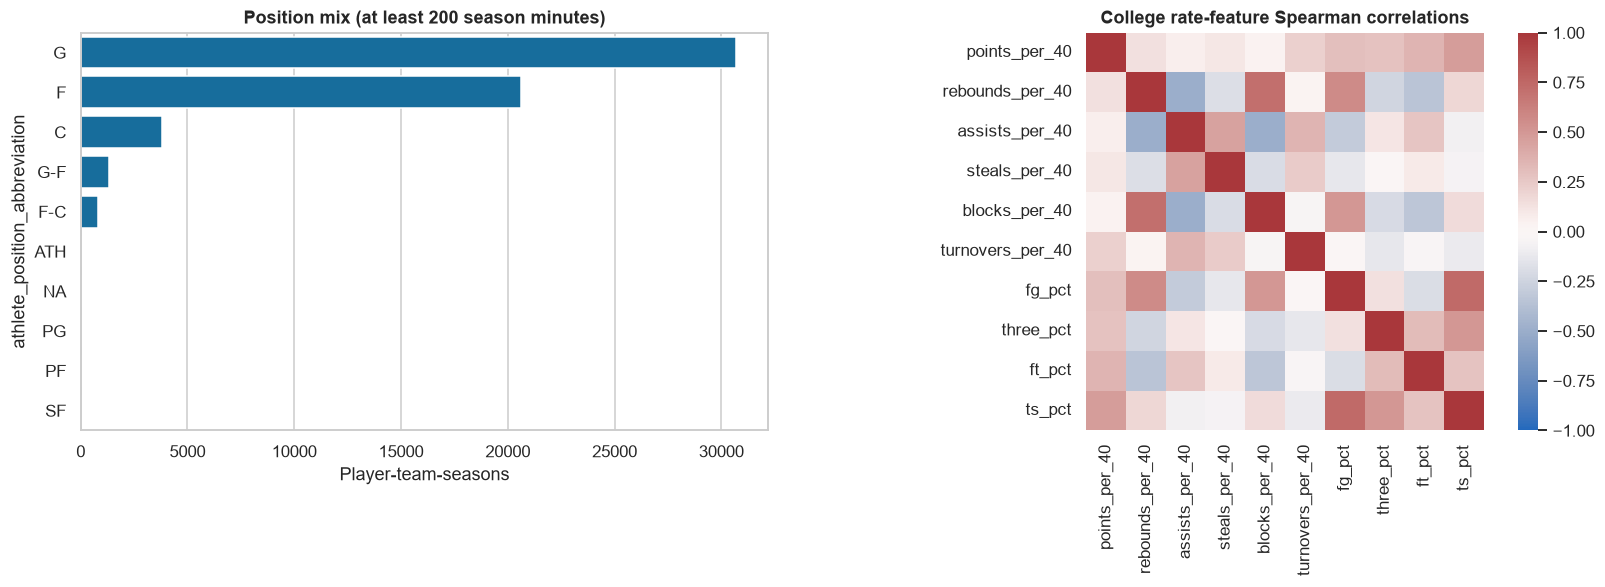

In [12]:
season_columns = [
    "season", "athlete_id", "team_id", "athlete_position_abbreviation",
    "games_on_roster", "games_played", "games_started", "minutes",
    "points", "rebounds", "assists", "steals", "blocks", "turnovers",
    "fg_pct", "three_pct", "ft_pct", "ts_pct",
    "points_per_40", "rebounds_per_40", "assists_per_40",
    "steals_per_40", "blocks_per_40", "turnovers_per_40",
]
college_season = load_dataset(
    "raw/college/player_season_from_box", columns=season_columns
)

college_coverage = (
    college_season.groupby("season", as_index=False)
    .agg(
        rows=("athlete_id", "size"),
        players=("athlete_id", "nunique"),
        teams=("team_id", "nunique"),
        games_on_roster=("games_on_roster", "sum"),
        minutes=("minutes", "sum"),
    )
)
team_counts = (
    college_season.groupby(["season", "athlete_id"], dropna=False)["team_id"]
    .nunique()
)
multi_team_player_seasons = int(team_counts.gt(1).sum())
season_key_duplicates = int(
    college_season.duplicated(
        ["season", "athlete_id", "team_id"], keep=False
    ).sum()
)
reconciliation = pd.DataFrame(
    {
        "check": [
            "player-season games_on_roster equals player-box rows",
            "multi-team player-seasons",
            "duplicate player-team-season rows",
        ],
        "value": [
            int(college_season["games_on_roster"].sum())
            == int(box_coverage["rows"].sum()),
            multi_team_player_seasons,
            season_key_duplicates,
        ],
    }
)
display(college_coverage)
display(reconciliation)

experienced = college_season.loc[
    pd.to_numeric(college_season["minutes"], errors="coerce").ge(200)
].copy()
rate_columns = [
    "points_per_40", "rebounds_per_40", "assists_per_40",
    "steals_per_40", "blocks_per_40", "turnovers_per_40",
    "fg_pct", "three_pct", "ft_pct", "ts_pct",
]
rate_correlation = experienced[rate_columns].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
position_counts = (
    experienced["athlete_position_abbreviation"]
    .fillna("Missing").value_counts().head(12)
)
sns.barplot(
    x=position_counts.values, y=position_counts.index,
    orient="h", ax=axes[0],
)
axes[0].set_title("Position mix (at least 200 season minutes)")
axes[0].set_xlabel("Player-team-seasons")
sns.heatmap(
    rate_correlation, cmap="vlag", center=0, vmin=-1, vmax=1,
    square=True, ax=axes[1],
)
axes[1].set_title("College rate-feature Spearman correlations")
plt.tight_layout()
plt.show()

,season,rows,players,dob_missing_pct,height_missing_pct,weight_missing_pct
0,2003,26,26,53.846,0.000,0.000
1,2004,275,275,33.091,0.364,0.364
2,2005,4602,4602,21.643,1.304,1.912
3,2006,4945,4945,40.364,1.800,3.721
4,2007,6531,6531,57.418,3.124,12.678
5,2008,6802,6802,58.453,2.514,12.585
6,2009,5296,5296,44.751,1.227,4.796
7,2010,5541,5541,29.922,1.173,5.649
8,2011,5440,5440,28.070,0.809,5.827
9,2012,5470,5470,32.413,1.042,5.265


,season,rows,teams,statistics,value_missing_pct
0,2003,23400,520,45,0.000
1,2004,24390,542,45,0.000
2,2005,24300,540,45,0.000
3,2006,24660,548,45,0.000
4,2007,25290,562,45,0.000
5,2008,24570,546,45,0.000
6,2009,24885,553,45,0.000
7,2010,27495,611,45,0.000
8,2011,27270,606,45,0.000
9,2012,27180,604,45,0.000


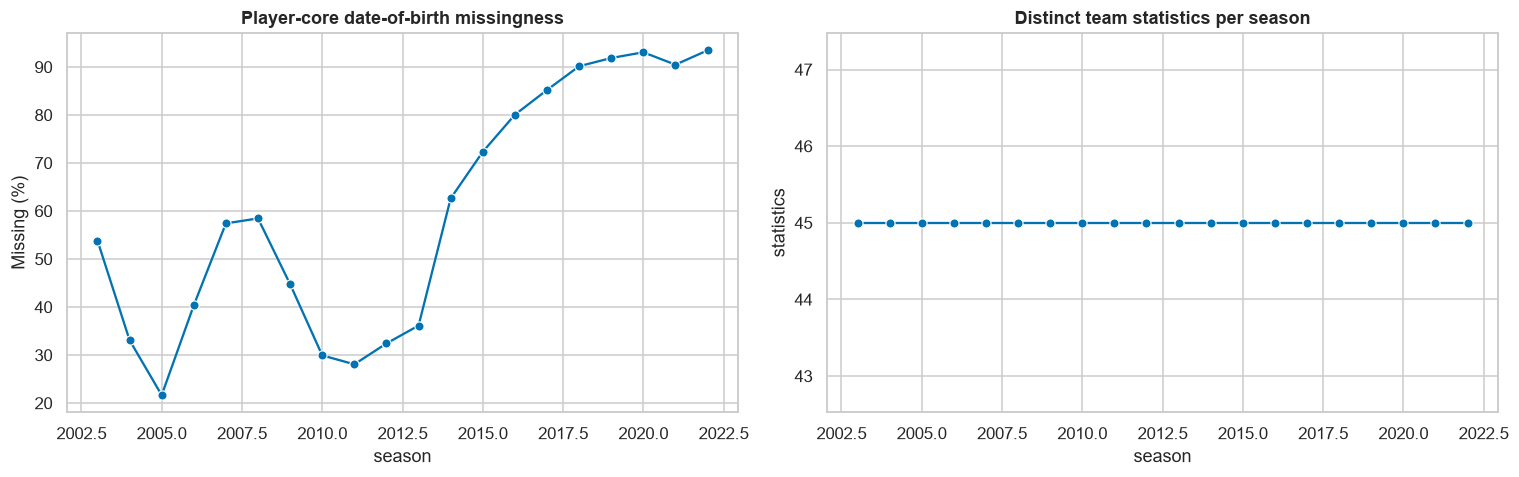

**Leakage note:** player-core draft_year, draft_round, and draft_selection describe draft outcomes/profile snapshots and are not automatically valid pre-draft predictors.

In [13]:
core_columns = [
    "season", "athlete_id", "age", "date_of_birth", "height", "weight",
    "position_abbreviation", "draft_year", "draft_round", "draft_selection",
]
college_core = load_dataset("raw/college/player_core", columns=core_columns)
core_by_year = (
    college_core.groupby("season", as_index=False)
    .agg(
        rows=("athlete_id", "size"),
        players=("athlete_id", "nunique"),
        dob_missing_pct=("date_of_birth", lambda x: 100 * x.isna().mean()),
        height_missing_pct=("height", lambda x: 100 * x.isna().mean()),
        weight_missing_pct=("weight", lambda x: 100 * x.isna().mean()),
    )
)

team_stat_columns = ["season", "team_id", "category", "stat_name", "value"]
college_team_stats = load_dataset(
    "raw/college/team_stats", columns=team_stat_columns
)
team_stats_by_year = (
    college_team_stats.groupby("season", as_index=False)
    .agg(
        rows=("stat_name", "size"),
        teams=("team_id", "nunique"),
        statistics=("stat_name", "nunique"),
        value_missing_pct=("value", lambda x: 100 * x.isna().mean()),
    )
)

display(core_by_year)
display(team_stats_by_year)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.lineplot(
    data=core_by_year, x="season", y="dob_missing_pct",
    marker="o", ax=axes[0],
)
axes[0].set_title("Player-core date-of-birth missingness")
axes[0].set_ylabel("Missing (%)")
sns.lineplot(
    data=team_stats_by_year, x="season", y="statistics",
    marker="o", ax=axes[1],
)
axes[1].set_title("Distinct team statistics per season")
plt.tight_layout()
plt.show()

display(
    Markdown(
        "**Leakage note:** player-core draft_year, draft_round, and "
        "draft_selection describe draft outcomes/profile snapshots and are not "
        "automatically valid pre-draft predictors."
    )
)

## 6. NBA draft and combine

Combine tables contain participant rosters even when a measurement block is blank. Availability is therefore reported both as roster rows and as rows with at least one observed measurement. Shooting missingness is strongly year-structured and should not be treated as missing at random.

,SEASON,selections,players,picks,organizations
0,2009,60,60,60,45
1,2010,60,60,60,47
2,2011,60,60,60,46
3,2012,60,60,60,40
4,2013,60,60,60,51
5,2014,60,60,60,44
6,2015,60,60,60,43
7,2016,60,60,60,45
8,2017,60,60,60,41
9,2018,60,60,60,45


ORGANIZATION_TYPE,,College/University,High School,Other Team/Club
SEASON,,,,
2009,0.000,78.333,0.000,21.667
2010,0.000,88.333,0.000,11.667
2011,0.000,78.333,0.000,21.667
2012,0.000,86.667,0.000,13.333
2013,0.000,78.333,0.000,21.667
2014,0.000,75.000,0.000,25.000
2015,0.000,76.667,1.667,21.667
2016,1.667,71.667,1.667,25.000
2017,0.000,83.333,0.000,16.667


,family,keys,equals_union
0,anthro,858,True
1,drills,858,True
2,spot_shooting,858,True
3,nonstationary_shooting,858,True


,_source_period,rows,observed_rows,family,observed_pct
0,2009,46,46,anthro,100.000
1,2010,52,52,anthro,100.000
2,2011,54,54,anthro,100.000
3,2012,61,61,anthro,100.000
4,2013,63,63,anthro,100.000
5,2014,56,56,anthro,100.000
6,2015,58,58,anthro,100.000
7,2016,56,56,anthro,100.000
8,2017,64,63,anthro,98.438
9,2018,69,69,anthro,100.000


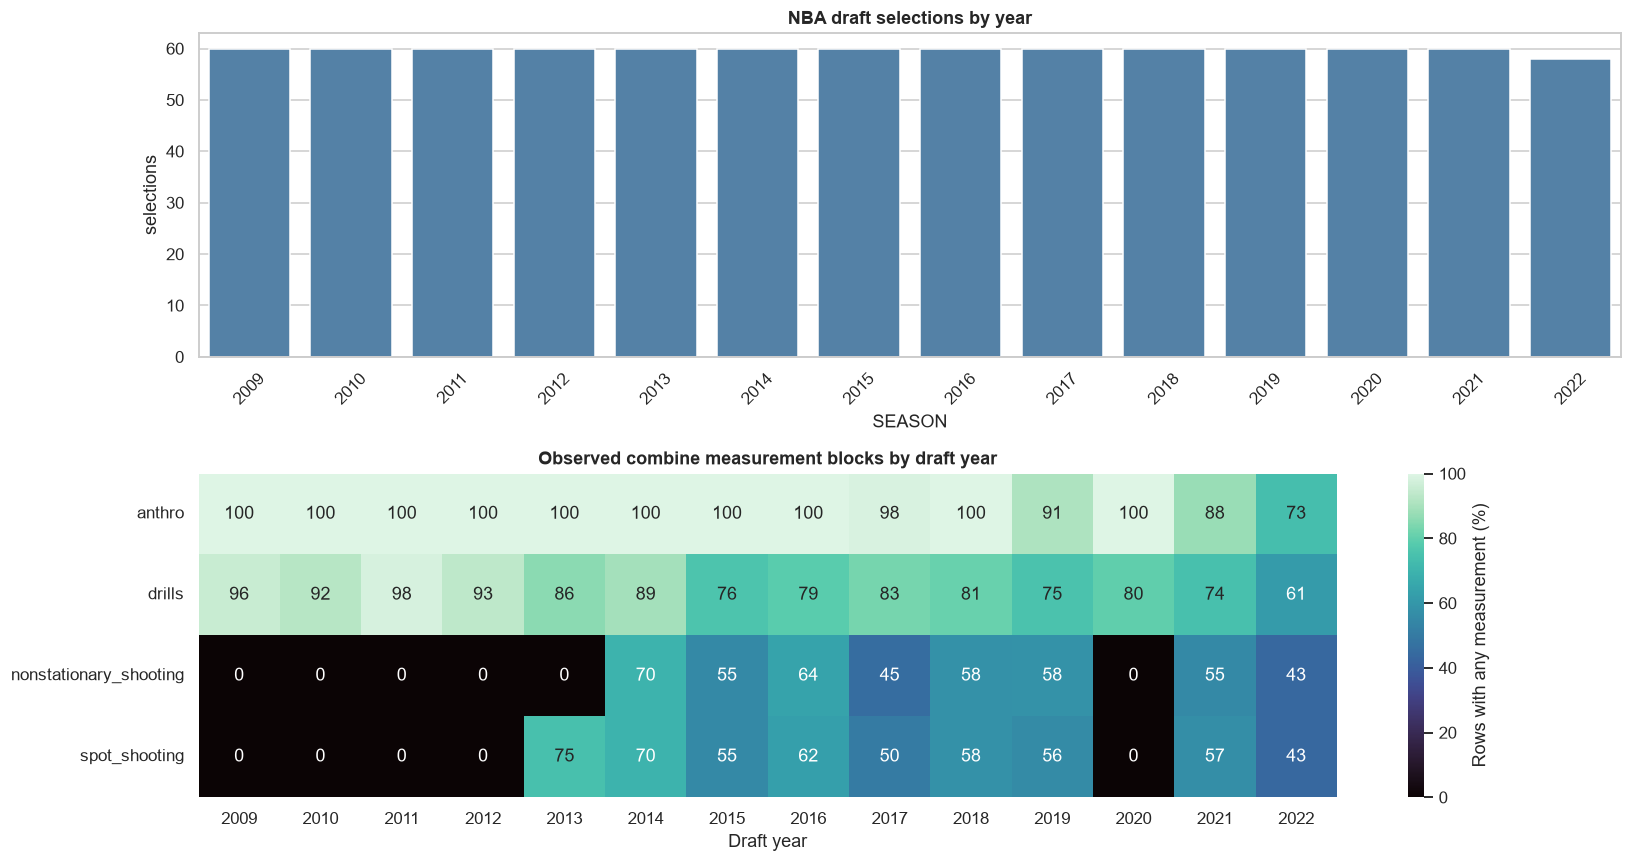

In [14]:
draft = load_dataset("raw/nba/draft")
combine_names = [
    "raw/nba/combine/anthro",
    "raw/nba/combine/drills",
    "raw/nba/combine/spot_shooting",
    "raw/nba/combine/nonstationary_shooting",
]
combine_frames = {name: load_dataset(name) for name in combine_names}

draft_by_year = (
    draft.groupby("SEASON", as_index=False)
    .agg(
        selections=("PERSON_ID", "size"),
        players=("PERSON_ID", "nunique"),
        picks=("OVERALL_PICK", "nunique"),
        organizations=("ORGANIZATION", "nunique"),
    )
)
organization_mix = pd.crosstab(
    draft["SEASON"], draft["ORGANIZATION_TYPE"], normalize="index"
).mul(100)

combine_coverage_rows = []
combine_key_sets = {}
for name, frame in combine_frames.items():
    family = name.rsplit("/", 1)[-1]
    identifier_columns = {
        "TEMP_PLAYER_ID", "PLAYER_ID", "FIRST_NAME", "LAST_NAME",
        "PLAYER_NAME", "POSITION", "_source_file", "_source_period",
    }
    measurement_columns = [
        column for column in frame.columns if column not in identifier_columns
    ]
    observed = frame[measurement_columns].notna().any(axis=1)
    grouped = (
        frame.assign(_observed=observed)
        .groupby("_source_period", as_index=False)
        .agg(rows=("TEMP_PLAYER_ID", "size"), observed_rows=("_observed", "sum"))
    )
    grouped["family"] = family
    grouped["observed_pct"] = 100 * grouped["observed_rows"] / grouped["rows"]
    combine_coverage_rows.append(grouped)
    combine_key_sets[family] = set(
        zip(frame["_source_period"].astype(str), frame["PLAYER_ID"])
    )

combine_coverage = pd.concat(combine_coverage_rows, ignore_index=True)
roster_union = set.union(*combine_key_sets.values())
roster_intersection = set.intersection(*combine_key_sets.values())
combine_roster_check = pd.DataFrame(
    {
        "family": list(combine_key_sets),
        "keys": [len(keys) for keys in combine_key_sets.values()],
        "equals_union": [
            keys == roster_union for keys in combine_key_sets.values()
        ],
    }
)

display(draft_by_year)
display(organization_mix)
display(combine_roster_check)
display(combine_coverage)

combine_matrix = combine_coverage.pivot(
    index="family", columns="_source_period", values="observed_pct"
)
fig, axes = plt.subplots(2, 1, figsize=(15, 8))
sns.barplot(
    data=draft_by_year, x="SEASON", y="selections", color="steelblue", ax=axes[0]
)
axes[0].set_title("NBA draft selections by year")
axes[0].tick_params(axis="x", rotation=45)
sns.heatmap(
    combine_matrix, cmap="mako", vmin=0, vmax=100, annot=True, fmt=".0f",
    cbar_kws={"label": "Rows with any measurement (%)"}, ax=axes[1],
)
axes[1].set_title("Observed combine measurement blocks by draft year")
axes[1].set_xlabel("Draft year")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()

### Height-with-shoes consistency failures

,_source_period,PLAYER_ID,PLAYER_NAME,POSITION,HEIGHT_WO_SHOES,HEIGHT_W_SHOES
446,2017,1628389,Edrice Adebayo,PF-C,80.750,75.750


### Combine shooting arithmetic

,family,shot_zones,made_over_attempt,comparable_percentages,percentage_mismatches
0,spot_shooting,15,0,2721,0
1,nonstationary_shooting,8,0,1080,0


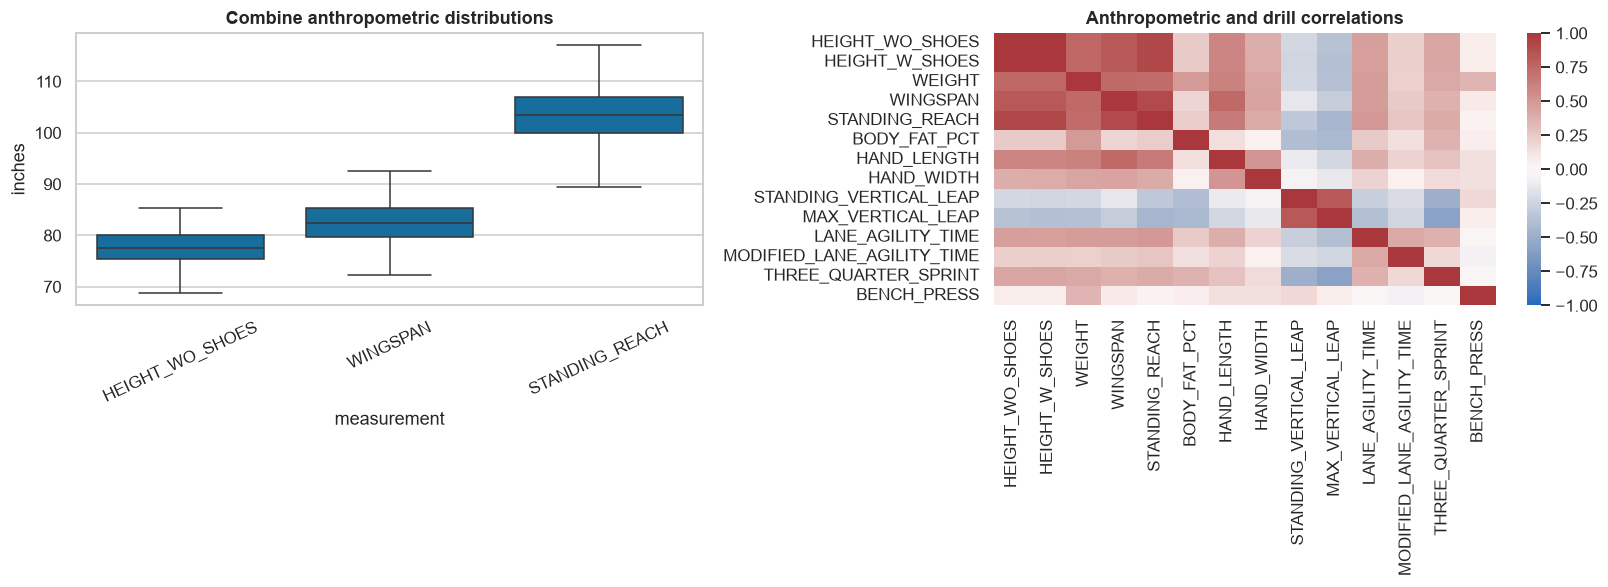

In [15]:
anthro = combine_frames["raw/nba/combine/anthro"]
drills = combine_frames["raw/nba/combine/drills"]

anthro_measurements = [
    "HEIGHT_WO_SHOES", "HEIGHT_W_SHOES", "WEIGHT", "WINGSPAN",
    "STANDING_REACH", "BODY_FAT_PCT", "HAND_LENGTH", "HAND_WIDTH",
]
drill_measurements = [
    "STANDING_VERTICAL_LEAP", "MAX_VERTICAL_LEAP", "LANE_AGILITY_TIME",
    "MODIFIED_LANE_AGILITY_TIME", "THREE_QUARTER_SPRINT", "BENCH_PRESS",
]

height_comparable = anthro[
    ["HEIGHT_WO_SHOES", "HEIGHT_W_SHOES"]
].notna().all(axis=1)
height_anomalies = anthro.loc[
    height_comparable
    & anthro["HEIGHT_W_SHOES"].lt(anthro["HEIGHT_WO_SHOES"]),
    [
        "_source_period", "PLAYER_ID", "PLAYER_NAME", "POSITION",
        "HEIGHT_WO_SHOES", "HEIGHT_W_SHOES",
    ],
]

combine_physical = anthro[
    ["_source_period", "PLAYER_ID", *anthro_measurements]
].merge(
    drills[["_source_period", "PLAYER_ID", *drill_measurements]],
    on=["_source_period", "PLAYER_ID"],
    how="inner",
)
combine_numeric = combine_physical[
    anthro_measurements + drill_measurements
].apply(pd.to_numeric, errors="coerce")
combine_correlation = combine_numeric.corr(method="spearman")


def audit_combine_shooting(name: str, frame: pd.DataFrame) -> dict:
    made_columns = [column for column in frame if column.endswith("_MADE")]
    made_over_attempt = 0
    percentage_mismatches = 0
    comparable_shots = 0
    for made_column in made_columns:
        root = made_column.removesuffix("_MADE")
        attempt_column = f"{root}_ATTEMPT"
        percentage_column = f"{root}_PCT"
        shots = frame[
            [made_column, attempt_column, percentage_column]
        ].apply(pd.to_numeric, errors="coerce")
        comparable = shots[[made_column, attempt_column]].notna().all(axis=1)
        made_over_attempt += int(
            (
                comparable
                & shots[made_column].gt(shots[attempt_column])
            ).sum()
        )
        valid_percentage = (
            shots[[made_column, attempt_column, percentage_column]]
            .notna().all(axis=1)
            & shots[attempt_column].gt(0)
        )
        comparable_shots += int(valid_percentage.sum())
        expected = shots[made_column] / shots[attempt_column]
        percentage_mismatches += int(
            (
                valid_percentage
                & ~np.isclose(
                    shots[percentage_column], expected,
                    atol=0.0015, rtol=0,
                )
            ).sum()
        )
    return {
        "family": name.rsplit("/", 1)[-1],
        "shot_zones": len(made_columns),
        "made_over_attempt": made_over_attempt,
        "comparable_percentages": comparable_shots,
        "percentage_mismatches": percentage_mismatches,
    }


shooting_checks = pd.DataFrame(
    [
        audit_combine_shooting(name, combine_frames[name])
        for name in [
            "raw/nba/combine/spot_shooting",
            "raw/nba/combine/nonstationary_shooting",
        ]
    ]
)

display(Markdown("### Height-with-shoes consistency failures"))
display(height_anomalies)
display(Markdown("### Combine shooting arithmetic"))
display(shooting_checks)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
anthro_for_plot = anthro.copy()
anthro_for_plot[anthro_measurements] = anthro_for_plot[
    anthro_measurements
].apply(pd.to_numeric, errors="coerce")
anthro_long = anthro_for_plot.melt(
    id_vars=["POSITION"],
    value_vars=["HEIGHT_WO_SHOES", "WINGSPAN", "STANDING_REACH"],
    var_name="measurement",
    value_name="inches",
).dropna()
sns.boxplot(
    data=anthro_long, x="measurement", y="inches",
    showfliers=False, ax=axes[0],
)
axes[0].set_title("Combine anthropometric distributions")
axes[0].tick_params(axis="x", rotation=25)
sns.heatmap(
    combine_correlation, cmap="vlag", center=0, vmin=-1, vmax=1,
    ax=axes[1],
)
axes[1].set_title("Anthropometric and drill correlations")
plt.tight_layout()
plt.show()

## 7. NBA player-season outcomes

Base and advanced rollups should have one row per player-season and identical keys. Extreme efficiency/ratings for tiny samples should be interpreted only with participation thresholds. A semantic check also tests whether advanced MIN behaves like minutes per game rather than season total minutes.

,check,value
0,base rows,8201
1,advanced rows,8201
2,base duplicate keys,0
3,advanced duplicate keys,0
4,base-only keys,0
5,advanced-only keys,0


### NBA base-stat arithmetic checks

,check,failures
0,negative counting-stat rows,0
1,made-over-attempt events,0
2,rebound identity mismatches,0
3,point identity mismatches,0


Correlation between advanced MIN and base total MIN / GP: **1.00000**. Values near one indicate that advanced MIN is minutes per game, not season-total minutes.

,SEASON,players,games,total_minutes,total_points,median_player_minutes,mean_ts_pct,mean_pie,points_per_player_game
0,2009-10,442,24813,"594,500.000",247100,"1,310.722",0.523,0.087,9.958
1,2010-11,452,25153,"595,050.000",244894,"1,236.029",0.514,0.077,9.736
2,2011-12,478,20758,"479,050.000",190594,939.380,0.500,0.084,9.182
3,2012-13,469,25757,"594,470.000",241223,"1,187.782",0.504,0.081,9.365
4,2013-14,482,25618,"595,199.850",248482,"1,136.084",0.511,0.079,9.700
5,2014-15,492,25981,"595,200.000",246035,"1,192.020",0.510,0.084,9.470
6,2015-16,476,26078,"594,850.000",252572,"1,228.934",0.525,0.088,9.685
7,2016-17,486,26139,"594,400.000",259753,"1,197.371",0.526,0.086,9.937
8,2017-18,540,26107,"593,850.000",261580,"1,038.763",0.529,0.078,10.020
9,2018-19,530,26101,"594,450.000",273573,"1,068.619",0.531,0.089,10.481


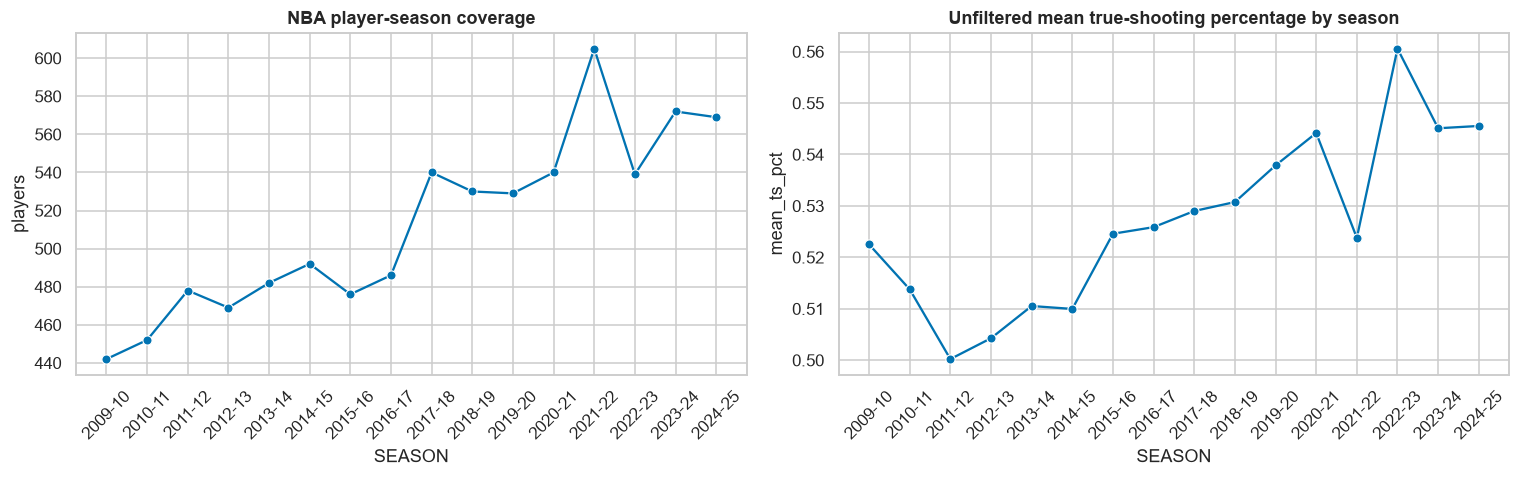

### Highest total minutes over the collected NBA window

,PLAYER_ID,PLAYER_NAME,MIN
440,201942,DeMar DeRozan,"41,227.623"
434,201935,James Harden,"40,009.437"
151,2544,LeBron James,"39,899.790"
377,201566,Russell Westbrook,"38,502.858"
323,201142,Kevin Durant,"35,582.257"
438,201939,Stephen Curry,"34,976.228"
223,101108,Chris Paul,"34,438.052"
448,201950,Jrue Holiday,"34,157.945"
296,200768,Kyle Lowry,"32,738.932"
325,201144,Mike Conley,"32,705.560"


In [16]:
nba_base = load_dataset("raw/nba/player_stats/base")
nba_advanced = load_dataset("raw/nba/player_stats/advanced")

base_keys = set(zip(nba_base["PLAYER_ID"], nba_base["SEASON"]))
advanced_keys = set(zip(nba_advanced["PLAYER_ID"], nba_advanced["SEASON"]))
key_parity = pd.DataFrame(
    {
        "check": [
            "base rows", "advanced rows", "base duplicate keys",
            "advanced duplicate keys", "base-only keys", "advanced-only keys",
        ],
        "value": [
            len(nba_base),
            len(nba_advanced),
            nba_base.duplicated(["PLAYER_ID", "SEASON"]).sum(),
            nba_advanced.duplicated(["PLAYER_ID", "SEASON"]).sum(),
            len(base_keys - advanced_keys),
            len(advanced_keys - base_keys),
        ],
    }
)

nba_join = nba_base[
    ["PLAYER_ID", "PLAYER_NAME", "SEASON", "GP", "MIN", "PTS"]
].merge(
    nba_advanced[
        [
            "PLAYER_ID", "SEASON", "MIN", "TS_PCT", "EFG_PCT", "USG_PCT",
            "OFF_RATING", "DEF_RATING", "NET_RATING", "PIE",
        ]
    ],
    on=["PLAYER_ID", "SEASON"],
    suffixes=("_base_total", "_advanced"),
    validate="one_to_one",
)
nba_join["base_minutes_per_game"] = (
    nba_join["MIN_base_total"] / nba_join["GP"].replace(0, np.nan)
)
minute_semantics_correlation = nba_join[
    ["base_minutes_per_game", "MIN_advanced"]
].corr().iloc[0, 1]

base_stat_columns = [
    "GP", "MIN", "FGM", "FGA", "FG3M", "FG3A", "FTM", "FTA",
    "OREB", "DREB", "REB", "AST", "TOV", "STL", "BLK", "PTS",
]
base_numeric = nba_base[base_stat_columns].apply(
    pd.to_numeric, errors="coerce"
)
base_made_over_attempt = sum(
    int(base_numeric[made].gt(base_numeric[attempted]).sum())
    for made, attempted in [
        ("FGM", "FGA"), ("FG3M", "FG3A"), ("FTM", "FTA")
    ]
)
valid_rebounds = base_numeric[["OREB", "DREB", "REB"]].notna().all(axis=1)
valid_points = base_numeric[["FGM", "FG3M", "FTM", "PTS"]].notna().all(axis=1)
base_domain_checks = pd.DataFrame(
    {
        "check": [
            "negative counting-stat rows",
            "made-over-attempt events",
            "rebound identity mismatches",
            "point identity mismatches",
        ],
        "failures": [
            int(base_numeric.lt(0).any(axis=1).sum()),
            base_made_over_attempt,
            int(
                (
                    valid_rebounds
                    & ~np.isclose(
                        base_numeric["OREB"] + base_numeric["DREB"],
                        base_numeric["REB"],
                    )
                ).sum()
            ),
            int(
                (
                    valid_points
                    & ~np.isclose(
                        2 * base_numeric["FGM"]
                        + base_numeric["FG3M"]
                        + base_numeric["FTM"],
                        base_numeric["PTS"],
                    )
                ).sum()
            ),
        ],
    }
)

nba_season_summary = (
    nba_join.groupby("SEASON", as_index=False)
    .agg(
        players=("PLAYER_ID", "nunique"),
        games=("GP", "sum"),
        total_minutes=("MIN_base_total", "sum"),
        total_points=("PTS", "sum"),
        median_player_minutes=("MIN_base_total", "median"),
        mean_ts_pct=("TS_PCT", "mean"),
        mean_pie=("PIE", "mean"),
    )
)
nba_season_summary["points_per_player_game"] = (
    nba_season_summary["total_points"] / nba_season_summary["games"]
)

display(key_parity)
display(Markdown("### NBA base-stat arithmetic checks"))
display(base_domain_checks)
display(
    Markdown(
        "Correlation between advanced MIN and base total MIN / GP: "
        f"**{minute_semantics_correlation:.5f}**. Values near one indicate "
        "that advanced MIN is minutes per game, not season-total minutes."
    )
)
display(nba_season_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.lineplot(
    data=nba_season_summary, x="SEASON", y="players",
    marker="o", ax=axes[0],
)
axes[0].set_title("NBA player-season coverage")
axes[0].tick_params(axis="x", rotation=45)
sns.lineplot(
    data=nba_season_summary, x="SEASON", y="mean_ts_pct",
    marker="o", ax=axes[1],
)
axes[1].set_title("Unfiltered mean true-shooting percentage by season")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

top_minutes = (
    nba_base.groupby(["PLAYER_ID", "PLAYER_NAME"], as_index=False)["MIN"]
    .sum().nlargest(15, "MIN")
)
display(Markdown("### Highest total minutes over the collected NBA window"))
display(top_minutes)

## 8. Processed modeling datasets

The 838-row drafted_players_all table is the population used by every current model configuration. The 659-row college-matched table is examined as a subset and selection mechanism—not silently substituted as the modeling population.

,population,rows,columns,unique_players,target_missing,zero_target
0,all drafted players,838,194,838,0,102
1,college-matched subset,659,194,659,0,36


College subset is exact: **True**

,identity_match_method,players
0,exact_name_unique,617
1,unmatched,179
2,exact_name_plus_org,42


,college_match,players,mean_pick,median_nba_minutes,reached_nba_pct,combine_available_pct
0,Matched,659,29.241,"2,317.110",94.537,83.005
1,Unmatched,179,34.810,277.222,63.128,26.257


,draft_year,drafted,college_matched,combine_roster,reached_nba,college_matched_pct,combine_roster_pct,reached_nba_pct
0,2009,60,47,39,46,78.333,65.000,76.667
1,2010,60,52,41,49,86.667,68.333,81.667
2,2011,60,45,43,51,75.000,71.667,85.000
3,2012,60,49,50,55,81.667,83.333,91.667
4,2013,60,43,45,49,71.667,75.000,81.667
5,2014,60,42,43,52,70.000,71.667,86.667
6,2015,60,44,37,44,73.333,61.667,73.333
7,2016,60,44,38,54,73.333,63.333,90.000
8,2017,60,50,42,56,83.333,70.000,93.333
9,2018,60,49,44,56,81.667,73.333,93.333


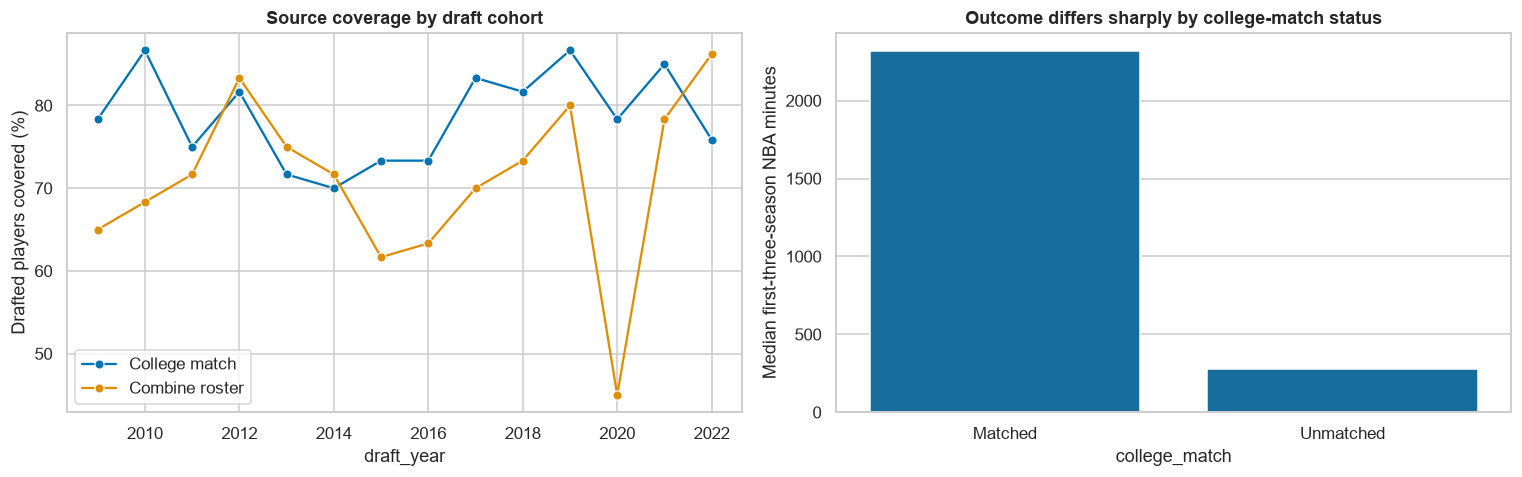

In [17]:
processed = load_dataset("processed/drafted_players_all").drop(
    columns=["_source_file", "_source_period"], errors="ignore"
)
college_model = load_dataset(
    "processed/model_dataset_drafted_college"
).drop(columns=["_source_file", "_source_period"], errors="ignore")

processed_keys = ["draft_year", "nba_player_id"]
expected_college_subset = (
    processed.loc[processed["has_college_data"].eq(1)]
    .sort_values(processed_keys).reset_index(drop=True)
)
actual_college_subset = (
    college_model.sort_values(processed_keys).reset_index(drop=True)
)
subset_equal = expected_college_subset.equals(actual_college_subset)

population_summary = pd.DataFrame(
    {
        "population": ["all drafted players", "college-matched subset"],
        "rows": [len(processed), len(college_model)],
        "columns": [processed.shape[1], college_model.shape[1]],
        "unique_players": [
            processed["nba_player_id"].nunique(),
            college_model["nba_player_id"].nunique(),
        ],
        "target_missing": [
            processed["nba_min_3y"].isna().sum(),
            college_model["nba_min_3y"].isna().sum(),
        ],
        "zero_target": [
            processed["nba_min_3y"].eq(0).sum(),
            college_model["nba_min_3y"].eq(0).sum(),
        ],
    }
)
match_method_counts = (
    processed["identity_match_method"].fillna("unmatched")
    .value_counts().rename_axis("identity_match_method")
    .rename("players").reset_index()
)
match_by_year = (
    processed.groupby("draft_year", as_index=False)
    .agg(
        drafted=("nba_player_id", "size"),
        college_matched=("has_college_data", "sum"),
        combine_roster=("combine_available", "sum"),
        reached_nba=("nba_reached_league_3y", "sum"),
    )
)
for column in ["college_matched", "combine_roster", "reached_nba"]:
    match_by_year[f"{column}_pct"] = (
        100 * match_by_year[column] / match_by_year["drafted"]
    )

selection_bias = (
    processed.assign(
        college_match=np.where(
            processed["has_college_data"].eq(1), "Matched", "Unmatched"
        )
    )
    .groupby("college_match", as_index=False)
    .agg(
        players=("nba_player_id", "size"),
        mean_pick=("overall_pick", "mean"),
        median_nba_minutes=("nba_min_3y", "median"),
        reached_nba_pct=(
            "nba_reached_league_3y", lambda x: 100 * x.mean()
        ),
        combine_available_pct=("combine_available", lambda x: 100 * x.mean()),
    )
)

display(population_summary)
display(Markdown(f"College subset is exact: **{subset_equal}**"))
display(match_method_counts)
display(selection_bias)
display(match_by_year)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.lineplot(
    data=match_by_year, x="draft_year", y="college_matched_pct",
    marker="o", label="College match", ax=axes[0],
)
sns.lineplot(
    data=match_by_year, x="draft_year", y="combine_roster_pct",
    marker="o", label="Combine roster", ax=axes[0],
)
axes[0].set_title("Source coverage by draft cohort")
axes[0].set_ylabel("Drafted players covered (%)")
sns.barplot(
    data=selection_bias, x="college_match", y="median_nba_minutes",
    ax=axes[1],
)
axes[1].set_title("Outcome differs sharply by college-match status")
axes[1].set_ylabel("Median first-three-season NBA minutes")
plt.tight_layout()
plt.show()

,family,columns,missing_cells,missing_pct
5,Combine movement shooting,24,18390,91.438
6,Combine spot shooting,45,33001,87.513
4,Combine drills,6,2563,50.975
3,Combine anthropometrics,8,2265,33.786
11,Pre-draft background,1,187,22.315
1,College last season,26,4747,21.787
0,College career,36,6489,21.510
2,College player core,2,360,21.480
8,Identity / matching,5,358,8.544
10,Post-draft NBA outcomes,32,1632,6.086


### Constant numeric fields

,column
0,combine_spot_fifteen_break_left_attempt
1,combine_spot_fifteen_top_key_attempt
2,combine_spot_fifteen_break_right_attempt
3,combine_spot_college_top_key_attempt
4,combine_spot_college_break_right_attempt
5,combine_spot_college_corner_right_attempt
6,combine_spot_nba_top_key_attempt
7,combine_spot_nba_corner_right_attempt


### Infinite-value fields

,column,infinite_values


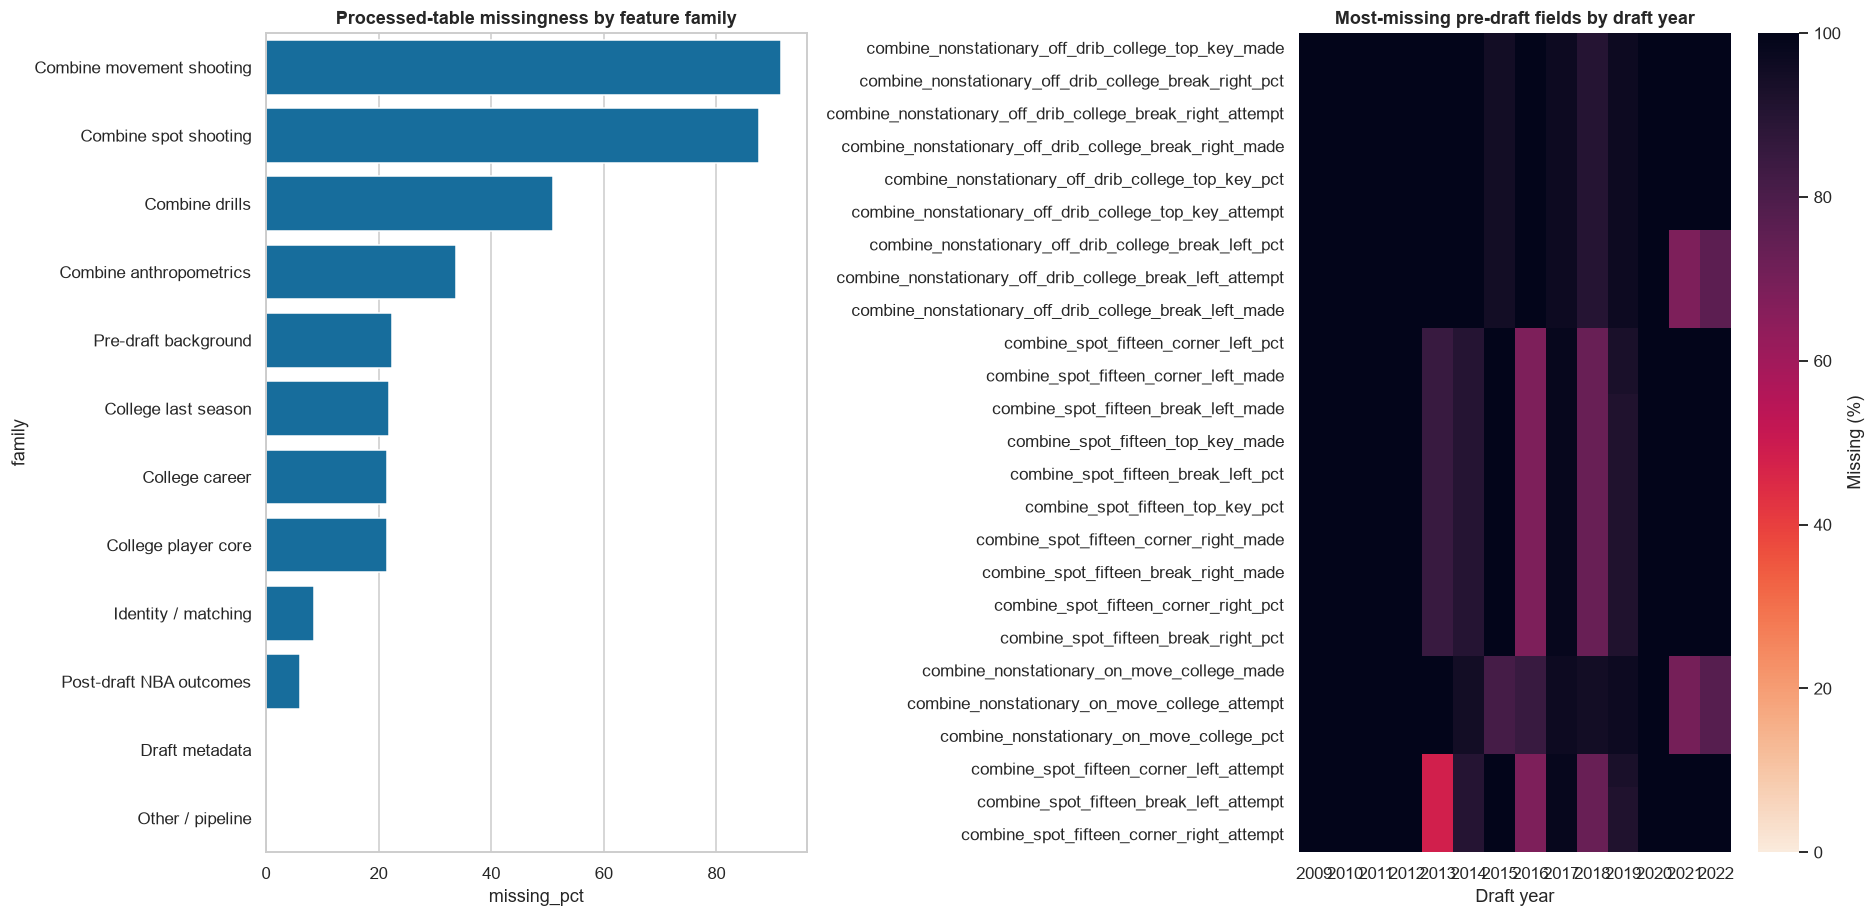

In [18]:
processed_missing = PROFILES[
    "processed/drafted_players_all"
]["missing"].copy()


def feature_family(column: str) -> str:
    if column in {
        "nba_player_id", "PLAYER_NAME", "normalized_name",
        "college_espn_id", "identity_match_method",
    }:
        return "Identity / matching"
    prefixes = [
        ("college_last_", "College last season"),
        ("college_career_", "College career"),
        ("college_core_", "College player core"),
        ("combine_anthro_", "Combine anthropometrics"),
        ("combine_drill_", "Combine drills"),
        ("combine_spot_", "Combine spot shooting"),
        ("combine_nonstationary_", "Combine movement shooting"),
        ("nba_", "Post-draft NBA outcomes"),
    ]
    if column == "age_on_draft_year_july1":
        return "Pre-draft background"
    for prefix, family in prefixes:
        if column.startswith(prefix):
            return family
    if column in {
        "overall_pick", "round_number", "round_pick", "TEAM_ABBREVIATION",
        "ORGANIZATION", "ORGANIZATION_TYPE",
    }:
        return "Draft metadata"
    return "Other / pipeline"


processed_missing["family"] = processed_missing["column"].map(feature_family)
family_missing = (
    processed_missing.groupby("family", as_index=False)
    .agg(
        columns=("column", "size"),
        missing_cells=("missing_rows", "sum"),
    )
)
family_missing["missing_pct"] = (
    100
    * family_missing["missing_cells"]
    / (len(processed) * family_missing["columns"])
)
family_missing = family_missing.sort_values("missing_pct", ascending=False)

pre_draft_missing = processed_missing[
    ~processed_missing["family"].isin(
        ["Post-draft NBA outcomes", "Identity / matching"]
    )
].sort_values("missing_pct", ascending=False)
top_year_columns = pre_draft_missing.head(25)["column"].tolist()
missing_by_year = (
    processed.groupby("draft_year")[top_year_columns]
    .agg(lambda series: 100 * series.isna().mean())
)

numeric_columns = processed.select_dtypes(include=np.number).columns
constant_numeric = [
    column for column in numeric_columns
    if processed[column].nunique(dropna=True) <= 1
]
infinite_counts = (
    processed[numeric_columns]
    .replace([np.inf, -np.inf], np.nan)
    .isna().sum()
    - processed[numeric_columns].isna().sum()
)
infinite_columns = infinite_counts[infinite_counts.gt(0)].sort_values(
    ascending=False
)

display(family_missing)
display(Markdown("### Constant numeric fields"))
display(pd.DataFrame({"column": constant_numeric}))
display(Markdown("### Infinite-value fields"))
display(
    infinite_columns.rename("infinite_values").rename_axis("column").reset_index()
)

fig, axes = plt.subplots(
    1, 2, figsize=(17, max(5, 0.34 * len(top_year_columns)))
)
sns.barplot(
    data=family_missing, x="missing_pct", y="family",
    orient="h", ax=axes[0],
)
axes[0].set_title("Processed-table missingness by feature family")
sns.heatmap(
    missing_by_year.T, cmap="rocket_r", vmin=0, vmax=100,
    cbar_kws={"label": "Missing (%)"}, ax=axes[1],
)
axes[1].set_title("Most-missing pre-draft fields by draft year")
axes[1].set_xlabel("Draft year")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()

,population,n,mean,median,std,zero_pct,max
0,all drafted players,838,"2,348.297","1,822.907","2,173.621",12.172,"9,028.050"
1,college-matched subset,659,"2,595.464","2,317.110","2,175.566",5.463,"9,028.050"


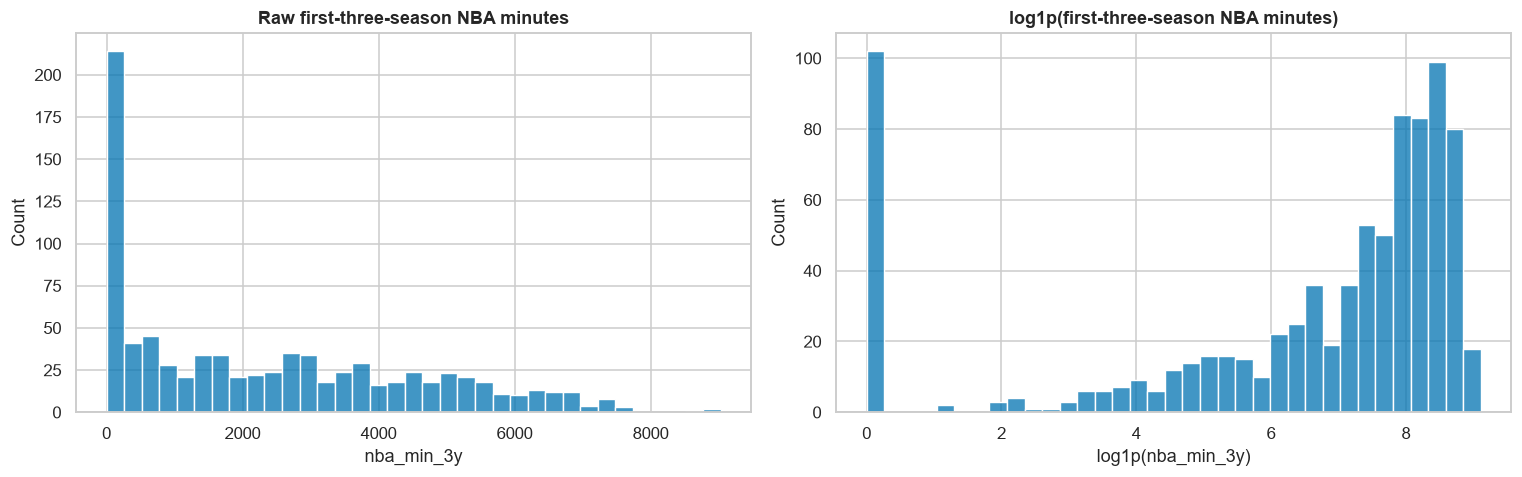

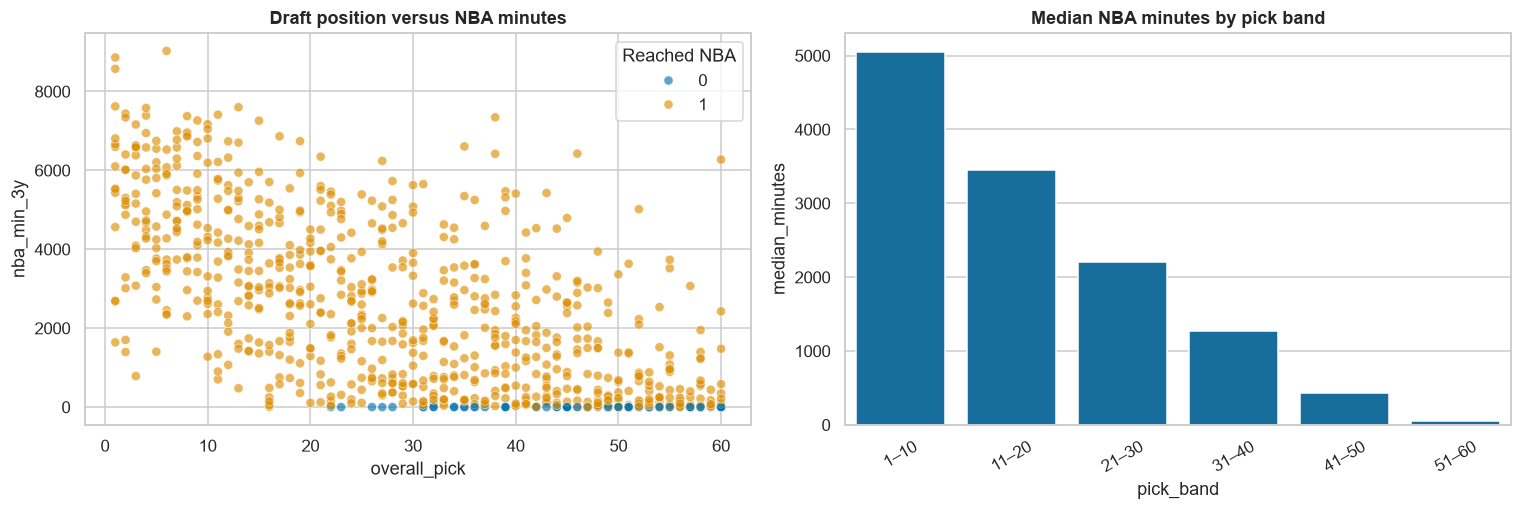

,pick_band,players,median_minutes,reached_nba_pct
0,1–10,140,"5,052.358",100.000
1,11–20,140,"3,450.798",100.000
2,21–30,140,"2,204.788",96.429
3,31–40,140,"1,267.725",90.000
4,41–50,140,430.034,79.286
5,51–60,138,47.477,60.870


In [19]:
target = "nba_min_3y"
target_summary = pd.DataFrame(
    {
        "population": ["all drafted players", "college-matched subset"],
        "n": [len(processed), len(college_model)],
        "mean": [processed[target].mean(), college_model[target].mean()],
        "median": [processed[target].median(), college_model[target].median()],
        "std": [processed[target].std(), college_model[target].std()],
        "zero_pct": [
            100 * processed[target].eq(0).mean(),
            100 * college_model[target].eq(0).mean(),
        ],
        "max": [processed[target].max(), college_model[target].max()],
    }
)
display(target_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.histplot(processed[target], bins=35, ax=axes[0])
axes[0].set_title("Raw first-three-season NBA minutes")
sns.histplot(np.log1p(processed[target]), bins=35, ax=axes[1])
axes[1].set_title("log1p(first-three-season NBA minutes)")
axes[1].set_xlabel("log1p(nba_min_3y)")
plt.tight_layout()
plt.show()

pick_bins = pd.cut(
    processed["overall_pick"],
    bins=[0, 10, 20, 30, 40, 50, 60],
    labels=["1–10", "11–20", "21–30", "31–40", "41–50", "51–60"],
)
pick_summary = (
    processed.assign(pick_band=pick_bins)
    .groupby("pick_band", observed=True, as_index=False)
    .agg(
        players=("nba_player_id", "size"),
        median_minutes=(target, "median"),
        reached_nba_pct=("nba_reached_league_3y", lambda x: 100 * x.mean()),
    )
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
sns.scatterplot(
    data=processed, x="overall_pick", y=target,
    hue="nba_reached_league_3y", alpha=0.65, ax=axes[0],
)
axes[0].set_title("Draft position versus NBA minutes")
axes[0].legend(title="Reached NBA")
sns.barplot(
    data=pick_summary, x="pick_band", y="median_minutes", ax=axes[1],
)
axes[1].set_title("Median NBA minutes by pick band")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()
display(pick_summary)

,feature,spearman_rho,abs_rho,pairwise_n,coverage_pct,missing_pct
0,overall_pick,-0.700,0.700,838,100.000,0.000
1,round_number,-0.604,0.604,838,100.000,0.000
142,combine_nonstationary_off_drib_college_top_key...,0.539,0.539,13,1.551,98.449
145,combine_nonstationary_off_drib_college_break_r...,0.451,0.451,13,1.551,98.449
147,combine_nonstationary_off_drib_college_break_r...,0.355,0.355,13,1.551,98.449
2,round_pick,-0.350,0.350,838,100.000,0.000
144,combine_nonstationary_off_drib_college_top_key...,0.338,0.338,13,1.551,98.449
64,age_on_draft_year_july1,-0.294,0.294,651,77.685,22.315
140,combine_nonstationary_off_drib_college_break_l...,0.285,0.285,46,5.489,94.511
143,combine_nonstationary_off_drib_college_top_key...,0.284,0.284,13,1.551,98.449


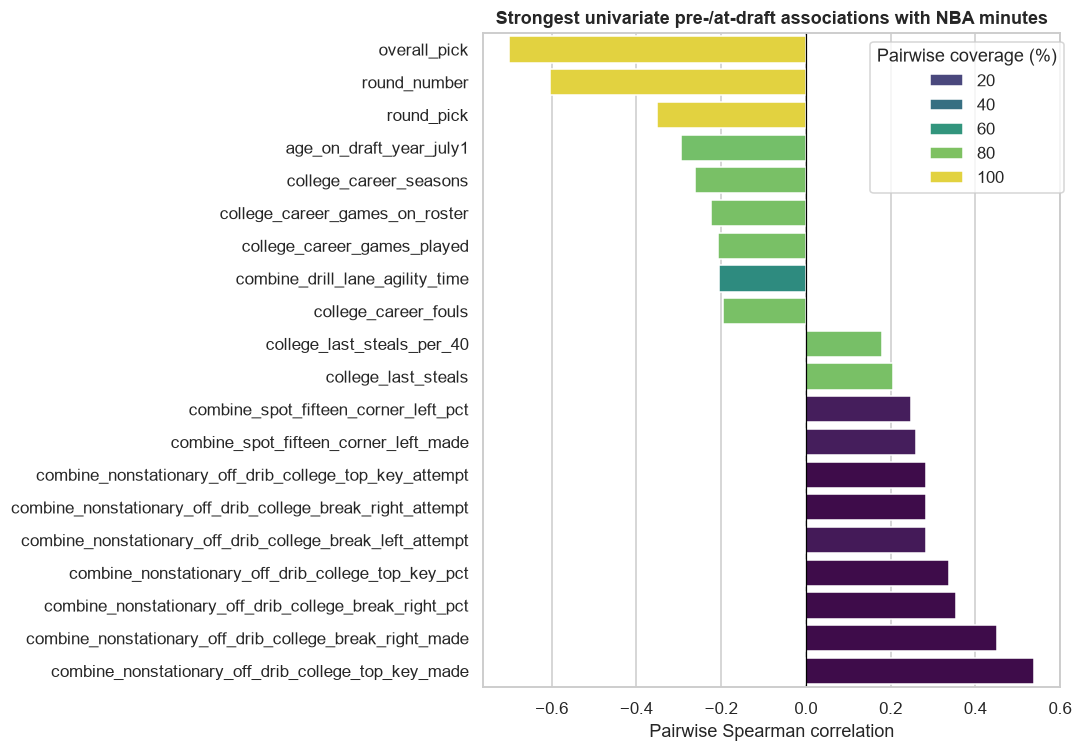

Pairwise sample size and coverage are shown because sparse combine features can have large-looking correlations on a small, selected participant subset. These are descriptive associations, not causal effects.

In [20]:
EXCLUDED_ASSOCIATION_COLUMNS = {
    "nba_player_id", "draft_year", "has_college_data", "combine_available"
}
candidate_features = [
    column
    for column in processed.select_dtypes(include=np.number).columns
    if not column.startswith("nba_")
    and column not in EXCLUDED_ASSOCIATION_COLUMNS
]


def pairwise_rank_correlation(
    frame: pd.DataFrame, features: list[str], target_column: str
) -> pd.DataFrame:
    rows = []
    for feature in features:
        pair = frame[[feature, target_column]].replace(
            [np.inf, -np.inf], np.nan
        ).dropna()
        if len(pair) < 3 or pair[feature].nunique() < 2:
            correlation = np.nan
        else:
            correlation = pair[feature].rank().corr(
                pair[target_column].rank()
            )
        rows.append(
            {
                "feature": feature,
                "spearman_rho": correlation,
                "abs_rho": abs(correlation) if pd.notna(correlation) else np.nan,
                "pairwise_n": len(pair),
                "coverage_pct": 100 * len(pair) / len(frame),
                "missing_pct": 100 * (1 - len(pair) / len(frame)),
            }
        )
    return pd.DataFrame(rows).sort_values(
        ["abs_rho", "pairwise_n"], ascending=[False, False]
    )


target_associations = pairwise_rank_correlation(
    processed, candidate_features, target
)
display(target_associations.head(30))

plot_associations = target_associations.dropna().head(20).sort_values(
    "spearman_rho"
)
fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(
    data=plot_associations, x="spearman_rho", y="feature",
    hue="coverage_pct", palette="viridis", dodge=False, ax=ax,
)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Strongest univariate pre-/at-draft associations with NBA minutes")
ax.set_xlabel("Pairwise Spearman correlation")
ax.set_ylabel("")
ax.legend(title="Pairwise coverage (%)", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

display(
    Markdown(
        "Pairwise sample size and coverage are shown because sparse combine "
        "features can have large-looking correlations on a small, selected "
        "participant subset. These are descriptive associations, not causal "
        "effects."
    )
)

,config,data_file,target,features,engineered_features,missing_features,post_draft_features,log_transform_target,train_end,validation,test
0,model_config.json,drafted_players_all.parquet,nba_min_3y,17,0,0,0,True,2017,2018–2019,2020–2022
1,xgboost_engineered.json,drafted_players_all.parquet,nba_min_3y,17,9,0,0,False,2017,2018–2019,2020–2022
2,xgboost_engineered_best.json,drafted_players_all.parquet,nba_min_3y,17,9,0,0,False,2017,2018–2019,2020–2022
3,xgboost_large.json,drafted_players_all.parquet,nba_min_3y,62,0,0,0,True,2017,2018–2019,2020–2022
4,xgboost_large_best.json,drafted_players_all.parquet,nba_min_3y,62,0,0,0,True,2017,2018–2019,2020–2022
5,xgboost_medium.json,drafted_players_all.parquet,nba_min_3y,30,0,0,0,True,2017,2018–2019,2020–2022
6,xgboost_medium_best.json,drafted_players_all.parquet,nba_min_3y,30,0,0,0,True,2017,2018–2019,2020–2022
7,xgboost_small.json,drafted_players_all.parquet,nba_min_3y,17,0,0,0,True,2017,2018–2019,2020–2022
8,xgboost_small_best.json,drafted_players_all.parquet,nba_min_3y,17,0,0,0,True,2017,2018–2019,2020–2022


,chronological_split,players,college_coverage_pct,combine_coverage_pct,median_pick,median_target,zero_target_pct
0,Test (2020–22),178,79.775,69.663,30.000,"2,030.372",6.742
1,Train (≤2017),540,77.037,70.000,30.500,"1,660.714",15.556
2,Validation (2018–19),120,84.167,76.667,30.500,"2,269.777",5.000


### Train-to-test drift for the recommended numeric features

,feature,train_n,test_n,train_mean,test_mean,standardized_mean_difference,abs_smd,train_missing_pct,test_missing_pct
1,age_on_draft_year_july1,409,141,21.336,20.649,-0.439,0.439,24.259,20.787
13,college_last_vs_career_turnovers_per_40,416,141,0.008,0.090,0.267,0.267,22.963,20.787
16,college_last_vs_career_three_attempt_rate,416,141,0.004,-0.004,-0.239,0.239,22.963,20.787
12,college_last_vs_career_blocks_per_40,416,141,-0.007,0.042,0.233,0.233,22.963,20.787
8,college_last_ft_pct,416,141,0.732,0.752,0.224,0.224,22.963,20.787
11,college_last_vs_career_steals_per_40,416,141,0.024,0.049,0.128,0.128,22.963,20.787
10,college_last_vs_career_points_per_40,416,141,1.641,1.415,-0.126,0.126,22.963,20.787
2,age_on_draft_year_july1_missing,540,178,0.243,0.208,-0.083,0.083,0.000,0.000
3,college_last_assists_per_40,416,141,3.071,3.217,0.078,0.078,22.963,20.787
15,college_last_vs_career_ft_pct,416,141,0.014,0.012,-0.067,0.067,22.963,20.787


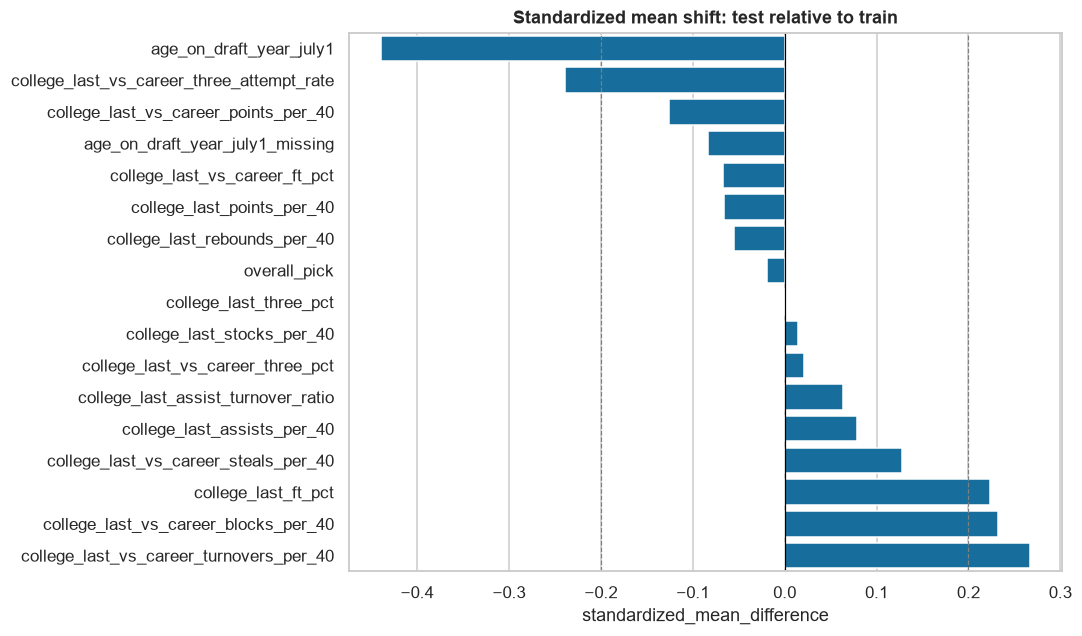

In [21]:
SRC_ROOT = REPO_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))
from feature_engineering import add_engineered_features


def configured_engineered_feature_names(config: dict) -> set[str]:
    settings = config.get("feature_engineering") or {}
    names = {
        f"{column}_missing"
        for column in settings.get("missing_indicators", [])
    }
    if settings.get("college_stocks_per_40", False):
        names.add("college_last_stocks_per_40")
    names.update(
        f"college_last_vs_career_{metric}"
        for metric in settings.get("college_last_vs_career", [])
    )
    return names


config_records = []
CONFIGS = {}
for path in sorted(CONFIG_ROOT.glob("*.json")):
    with path.open(encoding="utf-8") as file:
        config = json.load(file)
    CONFIGS[path.name] = config
    features = (
        config.get("numerical_features", [])
        + config.get("categorical_features", [])
    )
    engineered_features = configured_engineered_feature_names(config)
    available_features = set(processed.columns) | engineered_features
    config_records.append(
        {
            "config": path.name,
            "data_file": Path(config.get("data_path", "")).name,
            "target": config.get("target"),
            "features": len(features),
            "engineered_features": len(set(features) & engineered_features),
            "missing_features": len(set(features) - available_features),
            "post_draft_features": len(
                [feature for feature in features if feature.startswith("nba_")]
            ),
            "log_transform_target": config.get("log_transform_target", True),
            "train_end": config.get("split", {}).get("train_end"),
            "validation": (
                f"{config.get('split', {}).get('validation_start')}–"
                f"{config.get('split', {}).get('validation_end')}"
            ),
            "test": (
                f"{config.get('split', {}).get('test_start')}–"
                f"{config.get('split', {}).get('test_end')}"
            ),
        }
    )
config_summary = pd.DataFrame(config_records)
display(config_summary)

def chronological_split(year: pd.Series) -> pd.Series:
    return pd.Series(
        np.select(
            [
                year.le(2017),
                year.between(2018, 2019),
                year.between(2020, 2022),
            ],
            ["Train (≤2017)", "Validation (2018–19)", "Test (2020–22)"],
            default="Outside configured window",
        ),
        index=year.index,
    )


processed["chronological_split"] = chronological_split(
    processed["draft_year"]
)
split_summary = (
    processed.groupby("chronological_split", as_index=False)
    .agg(
        players=("nba_player_id", "size"),
        college_coverage_pct=("has_college_data", lambda x: 100 * x.mean()),
        combine_coverage_pct=("combine_available", lambda x: 100 * x.mean()),
        median_pick=("overall_pick", "median"),
        median_target=(target, "median"),
        zero_target_pct=(target, lambda x: 100 * x.eq(0).mean()),
    )
)
display(split_summary)

recommended_path = CONFIG_ROOT / "xgboost_engineered_best.json"
recommended_config = CONFIGS[recommended_path.name]
processed_for_config = add_engineered_features(
    processed, recommended_config
)
drift_features = [
    feature
    for feature in recommended_config.get("numerical_features", [])
    if feature in processed_for_config.columns
]


def standardized_mean_difference(
    frame: pd.DataFrame, features: list[str],
    group_column: str, left: str, right: str,
) -> pd.DataFrame:
    rows = []
    left_frame = frame[frame[group_column].eq(left)]
    right_frame = frame[frame[group_column].eq(right)]
    for feature in features:
        left_values = pd.to_numeric(left_frame[feature], errors="coerce")
        right_values = pd.to_numeric(right_frame[feature], errors="coerce")
        pooled_variance = (
            left_values.var(ddof=1) + right_values.var(ddof=1)
        ) / 2
        pooled_std = math.sqrt(pooled_variance) if pooled_variance > 0 else np.nan
        smd = (
            (right_values.mean() - left_values.mean()) / pooled_std
            if pd.notna(pooled_std) and pooled_std > 0
            else np.nan
        )
        rows.append(
            {
                "feature": feature,
                "train_n": left_values.notna().sum(),
                "test_n": right_values.notna().sum(),
                "train_mean": left_values.mean(),
                "test_mean": right_values.mean(),
                "standardized_mean_difference": smd,
                "abs_smd": abs(smd) if pd.notna(smd) else np.nan,
                "train_missing_pct": 100 * left_values.isna().mean(),
                "test_missing_pct": 100 * right_values.isna().mean(),
            }
        )
    return pd.DataFrame(rows).sort_values("abs_smd", ascending=False)


split_drift = standardized_mean_difference(
    processed_for_config,
    drift_features,
    "chronological_split",
    "Train (≤2017)",
    "Test (2020–22)",
)
display(Markdown("### Train-to-test drift for the recommended numeric features"))
display(split_drift)

if not split_drift.empty:
    fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(split_drift))))
    plot_drift = split_drift.dropna().sort_values(
        "standardized_mean_difference"
    )
    sns.barplot(
        data=plot_drift, x="standardized_mean_difference", y="feature", ax=ax
    )
    ax.axvline(0, color="black", linewidth=0.8)
    ax.axvline(-0.2, color="grey", linestyle="--", linewidth=0.8)
    ax.axvline(0.2, color="grey", linestyle="--", linewidth=0.8)
    ax.set_title("Standardized mean shift: test relative to train")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()

In [22]:
post_draft_outcomes = [
    column
    for column in processed.columns
    if column.startswith("nba_") and column != "nba_player_id"
]
identifier_fields = data_dictionary.loc[
    data_dictionary["Role"].isin(["Identifier", "Matching helper"]), "Column"
].tolist()
leakage_report = pd.DataFrame(
    [
        {
            "field_group": "Identifiers and matching helpers",
            "examples": ", ".join(identifier_fields[:6]),
            "prediction_timing": "Not predictors",
            "treatment": "Use only for joins, audits, and labels.",
        },
        {
            "field_group": "draft_year",
            "examples": "draft_year",
            "prediction_timing": "Split variable",
            "treatment": "Use for chronological splitting; avoid memorizing cohorts.",
        },
        {
            "field_group": "Draft selection metadata",
            "examples": "overall_pick, round_number, team",
            "prediction_timing": "Post-selection only",
            "treatment": "Use only in a clearly labeled post-selection baseline.",
        },
        {
            "field_group": "NBA three-year outcomes",
            "examples": ", ".join(post_draft_outcomes[:6]) + ", …",
            "prediction_timing": "Future information",
            "treatment": "Keep target(s) separate; never include as predictors.",
        },
        {
            "field_group": "College/combine measurements",
            "examples": "college_last_*, college_career_*, combine_*",
            "prediction_timing": "Pre-draft",
            "treatment": "Eligible after quality, denominator, and missingness review.",
        },
        {
            "field_group": "Pipeline flags",
            "examples": "identity_match_method, has_college_data, combine_available",
            "prediction_timing": "Audit / selection mechanism",
            "treatment": "Interpret as coverage signals, not causal basketball traits.",
        },
    ]
)
display(leakage_report)
display(
    Markdown(
        f"The processed table contains **{len(post_draft_outcomes)} nba_*** "
        "outcome fields. Current configuration checks above should show zero "
        "post-draft predictors."
    )
)

,field_group,examples,prediction_timing,treatment
0,Identifiers and matching helpers,"nba_player_id, PLAYER_NAME, normalized_name, c...",Not predictors,"Use only for joins, audits, and labels."
1,draft_year,draft_year,Split variable,Use for chronological splitting; avoid memoriz...
2,Draft selection metadata,"overall_pick, round_number, team",Post-selection only,Use only in a clearly labeled post-selection b...
3,NBA three-year outcomes,"nba_gp_3y, nba_min_3y, nba_pts_3y, nba_reb_3y,...",Future information,Keep target(s) separate; never include as pred...
4,College/combine measurements,"college_last_*, college_career_*, combine_*",Pre-draft,"Eligible after quality, denominator, and missi..."
5,Pipeline flags,"identity_match_method, has_college_data, combi...",Audit / selection mechanism,"Interpret as coverage signals, not causal bask..."


The processed table contains **32 nba_*** outcome fields. Current configuration checks above should show zero post-draft predictors.

## 9. Audit tables and cross-dataset consistency

These checks are diagnostic rather than fatal assertions: a warning should remain visible in an EDA notebook so it can be investigated. Audit previews are column-limited to avoid rendering 194-column rows.

In [23]:
audit_names = [
    name for name in DATASET_SPECS if name.startswith("processed/audit/")
]
audit_frames = {name: load_dataset(name) for name in audit_names}
audit_summary = pd.DataFrame(
    [
        {
            "audit": name.rsplit("/", 1)[-1],
            "rows": len(frame),
            "columns": frame.shape[1] - 2,
        }
        for name, frame in audit_frames.items()
    ]
)
display(audit_summary)

preferred_audit_columns = [
    "nba_player_id", "PLAYER_NAME", "draft_year", "overall_pick",
    "ORGANIZATION", "ORGANIZATION_TYPE", "normalized_name",
    "candidate_athlete_id", "candidate_name", "candidate_team",
]
for name, frame in audit_frames.items():
    visible = [
        column for column in preferred_audit_columns if column in frame.columns
    ]
    if not visible:
        visible = [
            column for column in frame.columns
            if not column.startswith("_source")
        ][:10]
    display(Markdown(f"### {name.rsplit('/', 1)[-1]}"))
    display(frame[visible].head(20))

C:\Users\WINDOWS\AppData\Local\Temp\ipykernel_16280\3019645168.py:40: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  frame["_source_file"] = path.name
C:\Users\WINDOWS\AppData\Local\Temp\ipykernel_16280\3019645168.py:41: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  frame["_source_period"] = extract_period(path)
C:\Users\WINDOWS\AppData\Local\Temp\ipykernel_16280\3019645168.py:40: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Cons

,audit,rows,columns
0,ambiguous_name_matches,20,8
1,drafted_players_without_college_match,179,194
2,drafted_players_without_identity_match,179,194


### ambiguous_name_matches

,nba_player_id,draft_year,candidate_name
0,202684,2011,Tristan Thompson
1,202684,2011,Tristan Thompson
2,203120,2012,Justin Hamilton
3,203120,2012,Justin Hamilton
4,203468,2013,CJ McCollum
5,203468,2013,Cj McCollum
6,203919,2014,Jordan Adams
7,203919,2014,Jordan Adams
8,203937,2014,Kyle Anderson
9,203937,2014,Kyle Anderson


### drafted_players_without_college_match

,nba_player_id,PLAYER_NAME,draft_year,overall_pick,ORGANIZATION,ORGANIZATION_TYPE,normalized_name
0,201937,Ricky Rubio,2009,5,Joventut Badalona (Spain),Other Team/Club,ricky rubio
1,201943,Brandon Jennings,2009,10,Pallacanestro Virtus Roma (Italy),Other Team/Club,brandon jennings
2,201964,Victor Claver,2009,22,Valencia BC (Spain),Other Team/Club,victor claver
3,201956,Omri Casspi,2009,23,Maccabi Tel Aviv B.C. (Israel),Other Team/Club,omri casspi
4,201958,Rodrigue Beaubois,2009,25,Cholet Basket (France),Other Team/Club,rodrigue beaubois
5,201963,Christian Eyenga,2009,30,CB Prat (Spain),Other Team/Club,christian eyenga
6,201968,Sergio Llull,2009,34,Real Madrid Baloncesto (Spain),Other Team/Club,sergio llull
7,201973,Jonas Jerebko,2009,39,Pallacanestro Biella (Italy),Other Team/Club,jonas jerebko
8,201994,Henk Norel,2009,47,Joventut Badalona (Spain),Other Team/Club,henk norel
9,201982,Sergiy Gladyr,2009,49,MBC Mykolaiv (Ukraine),Other Team/Club,sergiy gladyr


### drafted_players_without_identity_match

,nba_player_id,PLAYER_NAME,draft_year,overall_pick,ORGANIZATION,ORGANIZATION_TYPE,normalized_name
0,201937,Ricky Rubio,2009,5,Joventut Badalona (Spain),Other Team/Club,ricky rubio
1,201943,Brandon Jennings,2009,10,Pallacanestro Virtus Roma (Italy),Other Team/Club,brandon jennings
2,201964,Victor Claver,2009,22,Valencia BC (Spain),Other Team/Club,victor claver
3,201956,Omri Casspi,2009,23,Maccabi Tel Aviv B.C. (Israel),Other Team/Club,omri casspi
4,201958,Rodrigue Beaubois,2009,25,Cholet Basket (France),Other Team/Club,rodrigue beaubois
5,201963,Christian Eyenga,2009,30,CB Prat (Spain),Other Team/Club,christian eyenga
6,201968,Sergio Llull,2009,34,Real Madrid Baloncesto (Spain),Other Team/Club,sergio llull
7,201973,Jonas Jerebko,2009,39,Pallacanestro Biella (Italy),Other Team/Club,jonas jerebko
8,201994,Henk Norel,2009,47,Joventut Badalona (Spain),Other Team/Club,henk norel
9,201982,Sergiy Gladyr,2009,49,MBC Mykolaiv (Ukraine),Other Team/Club,sergiy gladyr


In [24]:
def compare_rollup_to_yearly(dataset_name: str) -> bool:
    spec = DATASET_SPECS[dataset_name]
    rollups = [
        path for path in spec["physical"] if base_name(path).endswith("_all")
    ]
    yearly = [
        path for path in spec["physical"] if not base_name(path).endswith("_all")
    ]
    if len(rollups) != 1 or not yearly:
        return False

    aggregate = pd.read_parquet(rollups[0])
    parts = []
    for path in yearly:
        part = pd.read_parquet(path)
        if "SEASON" in aggregate.columns and "SEASON" not in part.columns:
            part["SEASON"] = extract_period(path)
        parts.append(part)
    concatenated = pd.concat(parts, ignore_index=True, sort=False)
    concatenated = concatenated.reindex(columns=aggregate.columns)

    sort_candidates = [
        columns for columns in (
            ["SEASON", "PERSON_ID"],
            ["SEASON", "PLAYER_ID"],
        )
        if set(columns).issubset(aggregate.columns)
    ]
    sort_columns = sort_candidates[0] if sort_candidates else list(aggregate.columns)
    left = aggregate.sort_values(sort_columns).reset_index(drop=True)
    right = concatenated.sort_values(sort_columns).reset_index(drop=True)
    try:
        pd.testing.assert_frame_equal(
            left, right, check_dtype=False, check_like=False
        )
        return True
    except AssertionError:
        return False


draft_key_set = set(
    zip(pd.to_numeric(draft["SEASON"]), pd.to_numeric(draft["PERSON_ID"]))
)
processed_key_set = set(
    zip(
        pd.to_numeric(processed["draft_year"]),
        pd.to_numeric(processed["nba_player_id"]),
    )
)
college_key_set = set(
    zip(
        pd.to_numeric(college_model["draft_year"]),
        pd.to_numeric(college_model["nba_player_id"]),
    )
)

unmatched_college = audit_frames[
    "processed/audit/drafted_players_without_college_match"
].drop(columns=["_source_file", "_source_period"], errors="ignore")
unmatched_identity = audit_frames[
    "processed/audit/drafted_players_without_identity_match"
].drop(columns=["_source_file", "_source_period"], errors="ignore")
unmatched_key_set = set(
    zip(
        pd.to_numeric(unmatched_college["draft_year"]),
        pd.to_numeric(unmatched_college["nba_player_id"]),
    )
)

checks = [
    {
        "check": "NBA draft keys equal processed-player keys",
        "status": "PASS" if draft_key_set == processed_key_set else "FAIL",
        "value": len(draft_key_set.symmetric_difference(processed_key_set)),
        "detail": "Symmetric key difference; expected 0.",
    },
    {
        "check": "College model is exact has_college_data subset",
        "status": "PASS" if subset_equal else "FAIL",
        "value": subset_equal,
        "detail": "Exact dataframe comparison after key sort.",
    },
    {
        "check": "College subset and unmatched rows partition processed table",
        "status": (
            "PASS"
            if processed_key_set - college_key_set == unmatched_key_set
            else "FAIL"
        ),
        "value": len(
            (processed_key_set - college_key_set)
            .symmetric_difference(unmatched_key_set)
        ),
        "detail": "Symmetric key difference versus unmatched-college audit.",
    },
    {
        "check": "Two unmatched audit extracts are identical",
        "status": (
            "PASS" if unmatched_college.equals(unmatched_identity) else "WARN"
        ),
        "value": len(unmatched_college),
        "detail": "Current pipeline produces the same rows in both files.",
    },
    {
        "check": "NBA base and advanced keys match",
        "status": "PASS" if base_keys == advanced_keys else "FAIL",
        "value": len(base_keys.symmetric_difference(advanced_keys)),
        "detail": "Symmetric player-season key difference; expected 0.",
    },
    {
        "check": "Draft rollup equals yearly partitions",
        "status": (
            "PASS"
            if compare_rollup_to_yearly("raw/nba/draft")
            else "FAIL"
        ),
        "value": "",
        "detail": "Prevents rollup/yearly double counting.",
    },
    {
        "check": "NBA base rollup equals yearly partitions",
        "status": (
            "PASS"
            if compare_rollup_to_yearly("raw/nba/player_stats/base")
            else "FAIL"
        ),
        "value": "",
        "detail": "SEASON is reconstructed from filenames for comparison.",
    },
    {
        "check": "NBA advanced rollup equals yearly partitions",
        "status": (
            "PASS"
            if compare_rollup_to_yearly("raw/nba/player_stats/advanced")
            else "FAIL"
        ),
        "value": "",
        "detail": "SEASON is reconstructed from filenames for comparison.",
    },
    {
        "check": "All JSON mirrors match rows and schemas",
        "status": (
            "PASS"
            if json_audit[["row_match", "schema_match"]].all(axis=1).all()
            else "FAIL"
        ),
        "value": int(
            json_audit[["row_match", "schema_match"]].all(axis=1).sum()
        ),
        "detail": f"Out of {len(json_audit)} raw JSON files.",
    },
    {
        "check": "All four combine roster key sets match",
        "status": (
            "PASS"
            if len(roster_intersection) == len(roster_union)
            else "WARN"
        ),
        "value": len(roster_union) - len(roster_intersection),
        "detail": "Union minus intersection of player-year participant keys.",
    },
    {
        "check": "Data dictionary covers processed schema exactly",
        "status": (
            "PASS" if dictionary_columns == processed_columns else "FAIL"
        ),
        "value": len(dictionary_columns.symmetric_difference(processed_columns)),
        "detail": "Symmetric column-name difference; expected 0.",
    },
]
consistency_checks = pd.DataFrame(checks)
display(consistency_checks)

,check,status,value,detail
0,NBA draft keys equal processed-player keys,PASS,0,Symmetric key difference; expected 0.
1,College model is exact has_college_data subset,PASS,True,Exact dataframe comparison after key sort.
2,College subset and unmatched rows partition pr...,PASS,0,Symmetric key difference versus unmatched-coll...
3,Two unmatched audit extracts are identical,PASS,179,Current pipeline produces the same rows in bot...
4,NBA base and advanced keys match,PASS,0,Symmetric player-season key difference; expect...
5,Draft rollup equals yearly partitions,PASS,,Prevents rollup/yearly double counting.
6,NBA base rollup equals yearly partitions,PASS,,SEASON is reconstructed from filenames for com...
7,NBA advanced rollup equals yearly partitions,PASS,,SEASON is reconstructed from filenames for com...
8,All JSON mirrors match rows and schemas,PASS,102,Out of 102 raw JSON files.
9,All four combine roster key sets match,PASS,0,Union minus intersection of player-year partic...


In [25]:
age_invalid = processed[
    processed["age_on_draft_year_july1"].notna()
    & ~processed["age_on_draft_year_july1"].between(17, 30)
][
    [
        "nba_player_id", "PLAYER_NAME", "draft_year",
        "age_on_draft_year_july1", "college_espn_id",
    ]
]

combine_measurement_columns = [
    column
    for column in processed.columns
    if column.startswith("combine_") and column != "combine_available"
]
flagged_without_measurement = processed[
    processed["combine_available"].eq(1)
    & ~processed[combine_measurement_columns].notna().any(axis=1)
][
    [
        "nba_player_id", "PLAYER_NAME", "draft_year",
        "overall_pick", "combine_available",
    ]
]

percentage_columns = [
    column for column in processed.select_dtypes(include=np.number).columns
    if column.endswith("_pct") or "_pct_" in column
]
percentage_failures = []
for column in percentage_columns:
    values = processed[column].dropna()
    upper_bound = 100 if column == "combine_anthro_body_fat_pct" else 1
    invalid = values[~values.between(0, upper_bound)]
    if len(invalid):
        percentage_failures.append(
            {
                "column": column,
                "expected_range": f"[0, {upper_bound}]",
                "invalid_rows": len(invalid),
                "minimum": invalid.min(),
                "maximum": invalid.max(),
            }
        )

display(Markdown("### Implausible processed draft ages (outside 17–30)"))
display(age_invalid)
display(Markdown("### Combine roster flag but no numeric combine measurement"))
display(flagged_without_measurement)
display(Markdown("### Percentage fields outside [0, 1]"))
display(pd.DataFrame(
    percentage_failures,
    columns=[
        "column", "expected_range", "invalid_rows", "minimum", "maximum"
    ],
))

### Implausible processed draft ages (outside 17–30)

,nba_player_id,PLAYER_NAME,draft_year,age_on_draft_year_july1,college_espn_id
50,201984,Jack McClinton,2009,4.693,23242
53,201987,Robert Vaden,2009,4.728,22343


### Combine roster flag but no numeric combine measurement

,nba_player_id,PLAYER_NAME,draft_year,overall_pick,combine_available
480,1628365,Markelle Fultz,2017,1,1
600,1629627,Zion Williamson,2019,1,1
601,1629630,Ja Morant,2019,2,1
602,1629628,RJ Barrett,2019,3,1
603,1629631,De'Andre Hunter,2019,4,1
604,1629636,Darius Garland,2019,5,1
615,1629643,Chuma Okeke,2019,16,1
720,1630595,Cade Cunningham,2021,1,1
721,1630224,Jalen Green,2021,2,1
722,1630596,Evan Mobley,2021,3,1


### Percentage fields outside [0, 1]

,column,expected_range,invalid_rows,minimum,maximum


## 10. Automated findings and handoff

The statements below are computed from the current files. Re-run all cells after recollection or rebuilding the processed dataset; the conclusions will update with the data.

In [26]:
empty_names = dataset_summary.loc[
    dataset_summary["empty"], "dataset"
].tolist()
drift_names = (
    schema_drift["dataset"].drop_duplicates().tolist()
    if not schema_drift.empty else []
)
top_association = target_associations.dropna().iloc[0]
matched_row = selection_bias.set_index("college_match").loc["Matched"]
unmatched_row = selection_bias.set_index("college_match").loc["Unmatched"]
failed_consistency = consistency_checks[
    consistency_checks["status"].eq("FAIL")
]

findings = [
    (
        f"The data root contains {len(file_catalog):,} artifacts represented as "
        f"{len(DATASET_SPECS):,} logical tabular datasets; aggregate rollups and "
        "JSON provenance mirrors are not double-counted."
    ),
    (
        f"{len(empty_names)} logical datasets are empty/unavailable: "
        + ", ".join(empty_names) + "."
    ),
    (
        f"Schema drift appears in {len(drift_names)} partitioned dataset(s): "
        + (", ".join(drift_names) if drift_names else "none") + "."
    ),
    (
        f"All JSON/Parquet provenance checks passed for "
        f"{int(json_audit[['row_match', 'schema_match']].all(axis=1).sum())}"
        f"/{len(json_audit)} mirrors."
    ),
    (
        f"College data covers {int(processed['has_college_data'].sum())}/"
        f"{len(processed)} drafted players. Matched players have median "
        f"{matched_row['median_nba_minutes']:,.0f} NBA minutes versus "
        f"{unmatched_row['median_nba_minutes']:,.0f} for unmatched players, "
        "so complete-case analysis would select a systematically different population."
    ),
    (
        f"The primary target has {int(processed[target].eq(0).sum())} exact zeros "
        f"({100 * processed[target].eq(0).mean():.1f}%) and median "
        f"{processed[target].median():,.0f} minutes. Both raw and log1p views are "
        "needed because current configurations do not all use the same transform."
    ),
    (
        f"The strongest pairwise numeric association is "
        f"{top_association['feature']} (rho={top_association['spearman_rho']:.3f}, "
        f"n={int(top_association['pairwise_n'])}, "
        f"coverage={top_association['coverage_pct']:.1f}%)."
    ),
    (
        f"{len(age_invalid)} processed draft ages fall outside 17–30, "
        f"{len(height_anomalies)} combine rows have height-with-shoes below "
        f"height-without-shoes, and {len(flagged_without_measurement)} players "
        "have a combine roster flag without an observed numeric combine measurement."
    ),
    (
        f"{len(failed_consistency)} cross-dataset consistency checks failed."
    ),
]

display(Markdown("\n".join(f"- {finding}" for finding in findings)))

display(
    Markdown(
        "### Recommended modeling guardrails\n\n"
        "- Keep drafted_players_all as the population and fit imputers only on the training years.\n"
        "- Report the college-only subset as a selection-bias sensitivity analysis.\n"
        "- Compare a pre-draft feature model with a separately labeled post-selection draft-capital baseline.\n"
        "- Exclude every future nba_* outcome except the chosen target, and never use identifiers directly.\n"
        "- Add missingness indicators selectively for structurally sparse combine blocks and report pairwise sample sizes.\n"
        "- Investigate source anomalies before winsorizing or imputing them; preserve an auditable correction log."
    )
)

- The data root contains 323 artifacts represented as 20 logical tabular datasets; aggregate rollups and JSON provenance mirrors are not double-counted.
- 4 logical datasets are empty/unavailable: raw/college/player_stats, raw/college/rosters, raw/crosswalks/mbb_player_crosswalk, raw/crosswalks/nba_player_crosswalk.
- Schema drift appears in 5 partitioned dataset(s): raw/college/player_box, raw/nba/combine/anthro, raw/nba/combine/drills, raw/nba/combine/nonstationary_shooting, raw/nba/combine/spot_shooting.
- All JSON/Parquet provenance checks passed for 102/102 mirrors.
- College data covers 659/838 drafted players. Matched players have median 2,317 NBA minutes versus 277 for unmatched players, so complete-case analysis would select a systematically different population.
- The primary target has 102 exact zeros (12.2%) and median 1,823 minutes. Both raw and log1p views are needed because current configurations do not all use the same transform.
- The strongest pairwise numeric association is overall_pick (rho=-0.700, n=838, coverage=100.0%).
- 2 processed draft ages fall outside 17–30, 1 combine rows have height-with-shoes below height-without-shoes, and 28 players have a combine roster flag without an observed numeric combine measurement.
- 0 cross-dataset consistency checks failed.

### Recommended modeling guardrails

- Keep drafted_players_all as the population and fit imputers only on the training years.
- Report the college-only subset as a selection-bias sensitivity analysis.
- Compare a pre-draft feature model with a separately labeled post-selection draft-capital baseline.
- Exclude every future nba_* outcome except the chosen target, and never use identifiers directly.
- Add missingness indicators selectively for structurally sparse combine blocks and report pairwise sample sizes.
- Investigate source anomalies before winsorizing or imputing them; preserve an auditable correction log.